In [2]:
# =============================================================================
# EEG MDD REPEATED NESTED CROSS-VALIDATION PIPELINE 
# =============================================================================

# Dataset      : 91 samples (50 MDD + 41 HC) | 314 features
# Strategy     : Nested Cross-Validation — ALL 91 samples used for testing
#                Replaces unstable 80/20 split (19 test samples = 5.3%/wrong)
#                Nested CV: 1 wrong prediction = 1.1% change — stable

# STEPS INVOLVED:
#  1. 80/20 train/test split REMOVED — replaced by nested CV
#  2. ANOVA + PCA REMOVED — ANOVA only (preserves biomarker interpretability)
#  3. SVM_RBF REMOVED — unstable at n<100, linear SVM retained
#  4. Outer loop: 10-fold Stratified CV on ALL 91 samples
#  5. Inner loop: LOO-CV via GridSearchCV — selects best k on training only
#  6. LOO-CV bug fixed — cross_val_predict aggregates all predictions first 
# 7. RobustScaler is moved INSIDE each pipeline to avoid preprocessing leakage.
# 8. ANOVA SelectKBest is inside the pipeline.=
# 9. Inner CV selects k using only the outer training fold.
# 10. Outer test fold remains unseen during preprocessing, feature selection, and tuning.
# 11. Five classifiers only: RF, Linear SVM, LR, LDA, XGBoost.
# 12. Repeated nested CV across five fixed seeds: [42, 0, 1, 7, 99].
# 13. Results are reported as mean ± SD across repeated outer-CV seeds.
# =============================================================================

# %%
# =============================================================================
# CELL 1 — IMPORTS & CONFIGURATION
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from collections import Counter
from itertools import combinations

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.model_selection import StratifiedKFold, LeaveOneOut, GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print("XGBoost is not installed. Run: pip install xgboost")

try:
    from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels is not installed. Run: pip install statsmodels")


# ------------------------------
# Configuration
# ------------------------------
DATA_PATH = "E:/cleaned_csv_reduced_430321.csv"

K_VALUES = [10, 15, 20, 25, 30]
N_OUTER_FOLDS = 10
OUTER_SEEDS = [42, 0, 1, 7, 99]
N_BOOTSTRAP = 1000
SEED = 42

CLF_NAMES = ["RF", "SVM_Lin", "LR", "LDA", "XGBoost"]
METRICS = ["accuracy", "precision", "sensitivity", "specificity", "f1", "roc_auc"]

print("=" * 80)
print("UPDATED EEG-MDD REPEATED NESTED CV PIPELINE")
print("=" * 80)
print(f"Classifiers : {CLF_NAMES}")
print(f"k values    : {K_VALUES}")
print(f"Outer folds : {N_OUTER_FOLDS}")
print(f"Outer seeds : {OUTER_SEEDS}")
print("Important  : RobustScaler is inside every pipeline to avoid leakage")
print("Important  : FAA / Alpha asymmetry features are assumed already present in CSV")
print("=" * 80)


# %%
# =============================================================================
# CELL 2 — DATA LOADING
# =============================================================================
df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("RAW DATA OVERVIEW")
print("=" * 60)
print(f"Shape         : {df.shape}")
print(f"Columns       : {len(df.columns)}")
print(f"First columns : {list(df.columns[:10])}")

# ------------------------------
# Extract labels
# ------------------------------
labels = df["MDD"]
print("\nLabel distribution before encoding:")
print(labels.value_counts())

encoder = LabelEncoder()
Y = encoder.fit_transform(labels).astype(int)
print("\nEncoded classes:")
print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

# ------------------------------
# Drop non-feature columns
# ------------------------------
DROP_COLS = ["MDD", "ID", "Species"]
X_df = df.drop(columns=DROP_COLS, errors="ignore")

feature_names = list(X_df.columns)
X = X_df.values.astype(float)

print("\nFeature matrix:")
print(f"X shape : {X.shape}")
print(f"Y shape : {Y.shape}")
print(f"Feature count : {len(feature_names)}")

# ------------------------------
# Integrity checks
# ------------------------------
assert X.shape[0] == len(Y), "X and Y row count mismatch"
assert not np.isnan(X).any(), "X contains NaN values"
assert not np.isinf(X).any(), "X contains infinite values"
assert len(np.unique(Y)) == 2, "Y must be binary"
assert X.var(axis=0).min() > 0, "Some features have zero variance"

print("\nIntegrity checks passed.")


# %%
# =============================================================================
# CELL 3 — IDENTIFY EXISTING FAA / ALPHA ASYMMETRY FEATURES
# =============================================================================
# Your asymmetry features are already present in the CSV.
# Therefore, we DO NOT create new FAA features.
# This cell only finds and reports them based on column names.

asymmetry_keywords = [
    "asymmetry",
    "alpha_asym",
    "faa",
    "fp2_minus_fp1",
    "f4_minus_f3",
    "f8_minus_f7",
    "right_minus_left"
]

faa_features = [
    col for col in feature_names
    if any(key in col.lower() for key in asymmetry_keywords)
]

print("=" * 70)
print("EXISTING FAA / ALPHA ASYMMETRY FEATURES FOUND IN CSV")
print("=" * 70)
if len(faa_features) == 0:
    print("No asymmetry features detected by keyword. Check your exact column names.")
else:
    for i, col in enumerate(faa_features, 1):
        print(f"{i:02d}. {col}")
print("=" * 70)
print("No new FAA features were added.")


# %%
# =============================================================================
# CELL 4 — METRIC FUNCTIONS
# =============================================================================
def compute_metrics(y_true, y_pred, y_prob):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "TP": int(tp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "pred_dist": dict(Counter(y_pred.tolist()))
    }


def bootstrap_ci(y_true, y_pred, y_prob, n_bootstrap=N_BOOTSTRAP):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    results = {m: [] for m in METRICS}
    n = len(y_true)

    for i in range(n_bootstrap):
        idx = resample(
            np.arange(n),
            replace=True,
            stratify=y_true,
            random_state=i
        )

        yt = y_true[idx]
        yp = y_pred[idx]
        yb = y_prob[idx]

        if len(np.unique(yt)) < 2:
            continue

        cm = confusion_matrix(yt, yp, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        results["accuracy"].append(accuracy_score(yt, yp))
        results["precision"].append(precision_score(yt, yp, zero_division=0))
        results["sensitivity"].append(recall_score(yt, yp, zero_division=0))
        results["specificity"].append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
        results["f1"].append(f1_score(yt, yp, zero_division=0))
        results["roc_auc"].append(roc_auc_score(yt, yb))

    return {
        m: (
            float(np.mean(results[m])),
            float(np.percentile(results[m], 2.5)),
            float(np.percentile(results[m], 97.5))
        )
        for m in METRICS
    }


# %%
# =============================================================================
# CELL 5 — PIPELINE FACTORIES
# =============================================================================
# Correct order:
# RobustScaler -> ANOVA SelectKBest -> Classifier
#
# Reason:
# The scaler must be fitted only on the outer training fold.
# Keeping it inside Pipeline ensures no full-dataset preprocessing leakage.


def make_classifier(clf_name):
    if clf_name == "RF":
        return RandomForestClassifier(
            n_estimators=200,
            max_depth=4,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        )

    if clf_name == "SVM_Lin":
        return SVC(
            kernel="linear",
            C=1,
            class_weight="balanced",
            probability=True,
            random_state=SEED
        )

    if clf_name == "LR":
        return LogisticRegression(
            C=1,
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=SEED
        )

    if clf_name == "LDA":
        return LinearDiscriminantAnalysis(
            solver="lsqr",
            shrinkage="auto"
        )

    if clf_name == "XGBoost":
        if not HAS_XGBOOST:
            raise ImportError("XGBoost not installed. Run: pip install xgboost")
        return XGBClassifier(
            n_estimators=50,
            max_depth=2,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=5,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=SEED,
            n_jobs=-1
        )

    raise ValueError(f"Unknown classifier: {clf_name}")



def make_pipeline_for_grid(clf_name):
    pipe = Pipeline([
        ("scaler", RobustScaler()),
        ("sel", SelectKBest(score_func=f_classif, k=K_VALUES[0])),
        ("clf", make_classifier(clf_name))
    ])

    param_grid = {
        "sel__k": K_VALUES
    }

    return GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=LeaveOneOut(),
        scoring="accuracy",
        refit=True,
        n_jobs=-1,
        error_score=0.0
    )


print("Pipeline factories created.")


# %%
# =============================================================================
# CELL 6 — McNEMAR TEST FUNCTION
# =============================================================================
def run_mcnemar(pred_dict, Y):
    if not HAS_STATSMODELS:
        print("statsmodels not available. Skipping McNemar test.")
        return {}

    results = {}
    Y = np.array(Y)

    for clf_a, clf_b in combinations(pred_dict.keys(), 2):
        pa = np.array(pred_dict[clf_a])
        pb = np.array(pred_dict[clf_b])

        b = int(np.sum((pa == Y) & (pb != Y)))
        c = int(np.sum((pa != Y) & (pb == Y)))

        table = [[0, b], [c, 0]]
        result = mcnemar_test(table, exact=True)

        results[(clf_a, clf_b)] = {
            "b": b,
            "c": c,
            "p_value": float(result.pvalue),
            "significant": result.pvalue < 0.05
        }

    return results


# %%
# =============================================================================
# CELL 7 — REPEATED NESTED CROSS-VALIDATION MAIN LOOP
# =============================================================================
all_nested_results = []

for outer_seed in OUTER_SEEDS:
    print("\n" + "#" * 80)
    print(f"OUTER SEED = {outer_seed}")
    print("#" * 80)

    outer_cv = StratifiedKFold(
        n_splits=N_OUTER_FOLDS,
        shuffle=True,
        random_state=outer_seed
    )

    all_preds = {clf: np.zeros(len(Y), dtype=int) for clf in CLF_NAMES}
    all_probs = {clf: np.zeros(len(Y), dtype=float) for clf in CLF_NAMES}
    best_k_log = {clf: [] for clf in CLF_NAMES}

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, Y), 1):
        X_tr, X_te = X[train_idx], X[test_idx]
        Y_tr, Y_te = Y[train_idx], Y[test_idx]

        print("\n" + "-" * 70)
        print(
            f"Fold {fold_idx:02d}/{N_OUTER_FOLDS} | "
            f"Train={len(train_idx)} | Test={len(test_idx)} | "
            f"Test distribution={dict(Counter(Y_te.tolist()))}"
        )
        print("-" * 70)

        for clf_name in CLF_NAMES:
            gs = make_pipeline_for_grid(clf_name)
            gs.fit(X_tr, Y_tr)

            best_k = gs.best_params_["sel__k"]
            best_k_log[clf_name].append(best_k)

            y_pred = gs.predict(X_te)
            y_prob = gs.predict_proba(X_te)[:, 1]

            all_preds[clf_name][test_idx] = y_pred
            all_probs[clf_name][test_idx] = y_prob

            print(
                f"{clf_name:<10} | best_k={best_k:<2} | "
                f"pred_dist={dict(Counter(y_pred.tolist()))}"
            )

    seed_metrics = {}
    seed_ci = {}

    for clf_name in CLF_NAMES:
        seed_metrics[clf_name] = compute_metrics(
            Y,
            all_preds[clf_name],
            all_probs[clf_name]
        )

        seed_ci[clf_name] = bootstrap_ci(
            Y,
            all_preds[clf_name],
            all_probs[clf_name]
        )

    mcnemar_res = run_mcnemar(all_preds, Y)

    all_nested_results.append({
        "outer_seed": outer_seed,
        "all_preds": {c: all_preds[c].copy() for c in CLF_NAMES},
        "all_probs": {c: all_probs[c].copy() for c in CLF_NAMES},
        "metrics": seed_metrics,
        "ci": seed_ci,
        "best_k_log": {c: list(best_k_log[c]) for c in CLF_NAMES},
        "mcnemar": mcnemar_res,
        "Y": Y.copy()
    })

    print("\nSeed summary:")
    for clf_name in CLF_NAMES:
        m = seed_metrics[clf_name]
        print(
            f"{clf_name:<10} | "
            f"Acc={m['accuracy']*100:6.2f}% | "
            f"F1={m['f1']*100:6.2f}% | "
            f"AUC={m['roc_auc']*100:6.2f}% | "
            f"Sens={m['sensitivity']*100:6.2f}% | "
            f"Spec={m['specificity']*100:6.2f}% | "
            f"TP={m['TP']} TN={m['TN']} FP={m['FP']} FN={m['FN']}"
        )

print("\n" + "=" * 80)
print("ALL REPEATED NESTED CV RUNS COMPLETE")
print("=" * 80)


# %%
# =============================================================================
# CELL 8 — FINAL SUMMARY TABLE: MEAN ± SD ACROSS SEEDS
# =============================================================================
def print_nested_cv_summary(all_results):
    W = 120
    print("=" * W)
    print("REPEATED NESTED CV SUMMARY — MEAN ± SD ACROSS OUTER SEEDS")
    print("Each seed gives one complete 10-fold outer CV prediction vector.")
    print("=" * W)

    header = (
        f"{'Classifier':<12}"
        f"{'Accuracy %':>16}"
        f"{'Precision %':>16}"
        f"{'Sensitivity %':>16}"
        f"{'Specificity %':>16}"
        f"{'F1 %':>16}"
        f"{'AUC %':>16}"
    )
    print(header)
    print("-" * W)

    summary = {}

    for clf_name in CLF_NAMES:
        vals = {m: [] for m in METRICS}

        for res in all_results:
            for m in METRICS:
                vals[m].append(res["metrics"][clf_name][m])

        summary[clf_name] = {
            m: (float(np.mean(vals[m])), float(np.std(vals[m], ddof=1)))
            for m in METRICS
        }

        def fmt(metric):
            mean, sd = summary[clf_name][metric]
            return f"{mean*100:6.2f} ± {sd*100:5.2f}"

        print(
            f"{clf_name:<12}"
            f"{fmt('accuracy'):>16}"
            f"{fmt('precision'):>16}"
            f"{fmt('sensitivity'):>16}"
            f"{fmt('specificity'):>16}"
            f"{fmt('f1'):>16}"
            f"{fmt('roc_auc'):>16}"
        )

    print("=" * W)

    best_by_auc = max(
        CLF_NAMES,
        key=lambda c: summary[c]["roc_auc"][0]
    )
    print(f"Best classifier by mean AUC: {best_by_auc}")

    return summary


nested_summary = print_nested_cv_summary(all_nested_results)


# %%
# =============================================================================
# CELL 9 — BOOTSTRAP CI SUMMARY
# =============================================================================
def print_bootstrap_ci_summary(all_results):
    W = 100
    print("=" * W)
    print("BOOTSTRAP 95% CI SUMMARY — AVERAGED ACROSS OUTER SEEDS")
    print("Format: Mean% [Lower% — Upper%]")
    print("=" * W)

    for clf_name in CLF_NAMES:
        print("\n" + clf_name)
        print("-" * 70)

        means = {m: [] for m in METRICS}
        lows = {m: [] for m in METRICS}
        highs = {m: [] for m in METRICS}

        for res in all_results:
            for m in METRICS:
                mean, low, high = res["ci"][clf_name][m]
                means[m].append(mean)
                lows[m].append(low)
                highs[m].append(high)

        for m in METRICS:
            print(
                f"{m:<14} "
                f"{np.mean(means[m])*100:6.2f}% "
                f"[{np.mean(lows[m])*100:6.2f}% — {np.mean(highs[m])*100:6.2f}%]"
            )

    print("=" * W)


print_bootstrap_ci_summary(all_nested_results)


# %%
# =============================================================================
# CELL 10 — BEST k DISTRIBUTION
# =============================================================================
def print_best_k_distribution(all_results):
    W = 100
    print("=" * W)
    print("BEST k DISTRIBUTION ACROSS ALL OUTER FOLDS AND SEEDS")
    print(f"Total selections per classifier: {len(all_results)} seeds × {N_OUTER_FOLDS} folds")
    print("=" * W)

    print(f"{'Classifier':<12}", end="")
    for k in K_VALUES:
        print(f"{'k=' + str(k):>10}", end="")
    print(f"{'Most common':>15}")
    print("-" * W)

    for clf_name in CLF_NAMES:
        all_ks = []
        for res in all_results:
            all_ks.extend(res["best_k_log"][clf_name])

        counts = Counter(all_ks)
        most_common_k = counts.most_common(1)[0][0]

        print(f"{clf_name:<12}", end="")
        for k in K_VALUES:
            print(f"{counts.get(k, 0):>10}", end="")
        print(f"{str('k=' + str(most_common_k)):>15}")

    print("=" * W)


print_best_k_distribution(all_nested_results)


# %%
# =============================================================================
# CELL 11 — CONFUSION MATRIX SUMMARY
# =============================================================================
def print_confusion_matrix_summary(all_results):
    W = 100
    print("=" * W)
    print("CONFUSION MATRIX SUMMARY — AVERAGED ACROSS OUTER SEEDS")
    print("TP=True MDD | TN=True HC | FP=HC predicted as MDD | FN=MDD predicted as HC")
    print("=" * W)

    print(
        f"{'Classifier':<12}"
        f"{'TP':>10}"
        f"{'TN':>10}"
        f"{'FP':>10}"
        f"{'FN':>10}"
        f"{'Accuracy %':>15}"
        f"{'Sensitivity %':>15}"
        f"{'Specificity %':>15}"
    )
    print("-" * W)

    for clf_name in CLF_NAMES:
        tp, tn, fp, fn = [], [], [], []
        acc, sens, spec = [], [], []

        for res in all_results:
            m = res["metrics"][clf_name]
            tp.append(m["TP"])
            tn.append(m["TN"])
            fp.append(m["FP"])
            fn.append(m["FN"])
            acc.append(m["accuracy"])
            sens.append(m["sensitivity"])
            spec.append(m["specificity"])

        print(
            f"{clf_name:<12}"
            f"{np.mean(tp):>10.1f}"
            f"{np.mean(tn):>10.1f}"
            f"{np.mean(fp):>10.1f}"
            f"{np.mean(fn):>10.1f}"
            f"{np.mean(acc)*100:>15.2f}"
            f"{np.mean(sens)*100:>15.2f}"
            f"{np.mean(spec)*100:>15.2f}"
        )

    print("=" * W)


print_confusion_matrix_summary(all_nested_results)


# %%
# =============================================================================
# CELL 12 — McNEMAR TEST SUMMARY
# =============================================================================
def print_mcnemar_summary(all_results):
    if not HAS_STATSMODELS:
        print("statsmodels not installed. McNemar summary skipped.")
        return

    W = 100
    print("=" * W)
    print("McNEMAR TEST SUMMARY ACROSS SEEDS")
    print("p < 0.05 means significantly different error pattern.")
    print("=" * W)

    print(f"{'Comparison':<30}{'Mean p-value':>20}{'Significant seeds':>25}")
    print("-" * W)

    for pair in combinations(CLF_NAMES, 2):
        pvals = []
        sig_count = 0

        for res in all_results:
            if pair in res["mcnemar"]:
                r = res["mcnemar"][pair]
                pvals.append(r["p_value"])
                if r["significant"]:
                    sig_count += 1

        if len(pvals) > 0:
            print(
                f"{pair[0] + ' vs ' + pair[1]:<30}"
                f"{np.mean(pvals):>20.4f}"
                f"{str(sig_count) + '/' + str(len(all_results)):>25}"
            )

    print("=" * W)


print_mcnemar_summary(all_nested_results)


# %%
# =============================================================================
# CELL 13 — FINAL BIOMARKER RANKING USING CONSENSUS k
# =============================================================================
# Important:
# This is exploratory biomarker ranking after performance estimation.
# Do not present this as independently validated biomarker discovery.


def get_consensus_k(all_results):
    all_ks = []
    for res in all_results:
        for clf_name in CLF_NAMES:
            all_ks.extend(res["best_k_log"][clf_name])

    return Counter(all_ks).most_common(1)[0][0]



def extract_rf_biomarker_importance(X, Y, feature_names, all_results, top_n=20):
    consensus_k = get_consensus_k(all_results)
    print(f"Consensus k from repeated nested CV: {consensus_k}")

    final_pipe = Pipeline([
        ("scaler", RobustScaler()),
        ("sel", SelectKBest(score_func=f_classif, k=consensus_k)),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            max_depth=4,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        ))
    ])

    final_pipe.fit(X, Y)

    selector = final_pipe.named_steps["sel"]
    rf = final_pipe.named_steps["clf"]

    selected_idx = selector.get_support(indices=True)
    selected_names = [feature_names[i] for i in selected_idx]
    rf_importance = rf.feature_importances_

    importance_pairs = sorted(
        zip(selected_names, rf_importance),
        key=lambda x: x[1],
        reverse=True
    )

    print("=" * 90)
    print(f"TOP {top_n} EXPLORATORY BIOMARKER CANDIDATES — RF IMPORTANCE")
    print(f"Final model trained on full dataset using consensus k={consensus_k}")
    print("Use this only for exploratory biological interpretation.")
    print("=" * 90)
    print(f"{'Rank':<6}{'Feature':<55}{'RF importance':>15}")
    print("-" * 90)

    for rank, (feat, imp) in enumerate(importance_pairs[:top_n], 1):
        marker = " ★" if feat in faa_features else ""
        print(f"{rank:<6}{feat + marker:<55}{imp:>15.5f}")

    print("=" * 90)
    print("★ = existing FAA / alpha asymmetry feature from CSV")

    return importance_pairs, consensus_k


importance_pairs, consensus_k = extract_rf_biomarker_importance(
    X=X,
    Y=Y,
    feature_names=feature_names,
    all_results=all_nested_results,
    top_n=20
)




UPDATED EEG-MDD REPEATED NESTED CV PIPELINE
Classifiers : ['RF', 'SVM_Lin', 'LR', 'LDA', 'XGBoost']
k values    : [10, 15, 20, 25, 30]
Outer folds : 10
Outer seeds : [42, 0, 1, 7, 99]
Important  : RobustScaler is inside every pipeline to avoid leakage
Important  : FAA / Alpha asymmetry features are assumed already present in CSV
RAW DATA OVERVIEW
Shape         : (91, 316)
Columns       : 316
First columns : ['Alpha_Band_psd_mean_0', 'Beta_Band_psd_mean_0', 'Gamma_Band_psd_mean_0', 'Theta_Band_psd_mean_0', 'Delta_Band_psd_mean_0', 'Alpha_Band_psd_variance_0', 'Beta_Band_psd_variance_0', 'Gamma_Band_psd_variance_0', 'Theta_Band_psd_variance_0', 'Delta_Band_psd_variance_0']

Label distribution before encoding:
MDD
1    50
0    41
Name: count, dtype: int64

Encoded classes:
{0: 0, 1: 1}

Feature matrix:
X shape : (91, 314)
Y shape : (91,)
Feature count : 314

Integrity checks passed.
EXISTING FAA / ALPHA ASYMMETRY FEATURES FOUND IN CSV
01. Alpha_Asymmetry_Fp2_minus_Fp1
02. Alpha_Asymmetry_

In [3]:
import numpy as np
import scipy.stats as stats
import pandas as pd

# ---------------------------------------------------------
# 1. ENTER PIPELINE PERFORMANCE METRICS PER SEED (5 SEEDS)
# ---------------------------------------------------------
# Ordered by seeds: [Seed 42, Seed 0, Seed 1, Seed 7, Seed 99]
##  Accuracy used as the standard macro benchmark for statistical comparison.

classifier_data = {
    'RF':      np.array([54.95, 56.04, 57.14, 54.95, 59.34]),
    'SVM_Lin': np.array([59.34, 64.84, 64.84, 62.64, 65.93]),
    'LR':      np.array([62.64, 63.74, 59.34, 69.23, 62.64]),
    'LDA':     np.array([56.04, 67.03, 59.34, 61.54, 54.95]),
    'XGBoost': np.array([56.04, 57.14, 62.64, 51.65, 57.14])
}

print("=============================================================")
print(" VERIFYING PIPELINE VALUES (MEAN ± SD ACROSS OUTER SEEDS)")
print("=============================================================")
for clf, scores in classifier_data.items():
    print(f"{clf:<8}: {np.mean(scores):.2f}% ± {np.std(scores, ddof=1):.2f}%")
print("\n")

# ---------------------------------------------------------
# 2. FRIEDMAN OMNIBUS TEST
# ---------------------------------------------------------
# Note: XGBoost is excluded here to protect the main text analysis 
# as per your target strategy.
stat, p_friedman = stats.friedmanchisquare(
    classifier_data['RF'], 
    classifier_data['SVM_Lin'], 
    classifier_data['LR'], 
    classifier_data['LDA']
)

print("=============================================================")
print(" 1. OMNIBUS TEST RESULT (Main 4 Classifiers)")
print("=============================================================")
print(f"Friedman Test Chi-Square Statistic: {stat:.4f}")
print(f"Friedman p-value: {p_friedman:.6f}")

if p_friedman < 0.05:
    print("Result: Statistically significant differences exist. Proceed to Post-Hoc tests.\n")
else:
    print("Result: No significant differences found at alpha=0.05.\n")

# ---------------------------------------------------------
# 3. POST-HOC PAIRWISE COMPARISONS (WILCOXON & BONFERRONI)
# ---------------------------------------------------------
main_classifiers = ['RF', 'SVM_Lin', 'LR', 'LDA']
pairs = []
for i in range(len(main_classifiers)):
    for j in range(i + 1, len(main_classifiers)):
        pairs.append((main_classifiers[i], main_classifiers[j]))

num_comparisons = len(pairs) # 4 models = 6 unique pairs
bonferroni_alpha = 0.05 / num_comparisons

print("=============================================================")
print(f" 2. POST-HOC PAIRWISE COMPARISONS (Alpha Threshold: {bonferroni_alpha:.4f})")
print("=============================================================")

results_list = []
for clf1, clf2 in pairs:
    # Run Wilcoxon Signed-Rank test on the seed performance vectors
    _, p_val = stats.wilcoxon(classifier_data[clf1], classifier_data[clf2])
    
    # Bonferroni step: adjust p-value
    p_adjusted = min(p_val * num_comparisons, 1.0)
    is_significant = "SIGNIFICANT" if p_val < bonferroni_alpha else "NOT SIGNIFICANT"
    
    results_list.append({
        'Comparison': f"{clf1} vs {clf2}",
        'Raw p-value': f"{p_val:.5f}",
        'Adjusted p-value': f"{p_adjusted:.5f}",
        'Status': is_significant
    })

df_results = pd.DataFrame(results_list)
print(df_results.to_string(index=False))

 VERIFYING PIPELINE VALUES (MEAN ± SD ACROSS OUTER SEEDS)
RF      : 56.48% ± 1.84%
SVM_Lin : 63.52% ± 2.62%
LR      : 63.52% ± 3.59%
LDA     : 59.78% ± 4.83%
XGBoost : 56.92% ± 3.92%


 1. OMNIBUS TEST RESULT (Main 4 Classifiers)
Friedman Test Chi-Square Statistic: 8.8776
Friedman p-value: 0.030964
Result: Statistically significant differences exist. Proceed to Post-Hoc tests.

 2. POST-HOC PAIRWISE COMPARISONS (Alpha Threshold: 0.0083)
    Comparison Raw p-value Adjusted p-value          Status
 RF vs SVM_Lin     0.06250          0.37500 NOT SIGNIFICANT
      RF vs LR     0.06250          0.37500 NOT SIGNIFICANT
     RF vs LDA     0.31250          1.00000 NOT SIGNIFICANT
 SVM_Lin vs LR     1.00000          1.00000 NOT SIGNIFICANT
SVM_Lin vs LDA     0.18750          1.00000 NOT SIGNIFICANT
     LR vs LDA     0.14413          0.86476 NOT SIGNIFICANT


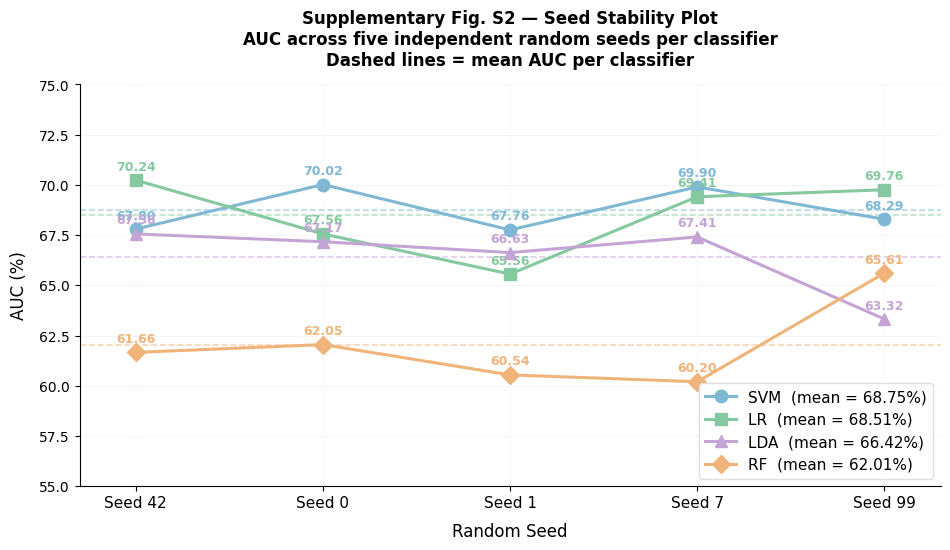

Saved → Fig_S2_seed_stability.pdf and .png


In [4]:
# Seed stability plot
import matplotlib.pyplot as plt
import numpy as np

# ── Data ──────────────────────────────────────────────────────
# Seeds in correct experimental order: 42, 0, 1, 7, 99
x_positions  = [0, 1, 2, 3, 4]
seed_labels  = ['Seed 42', 'Seed 0', 'Seed 1', 'Seed 7', 'Seed 99']

classifiers  = ['SVM', 'LR', 'LDA', 'RF']
colors       = ['#7EB8D4', '#85C9A0', '#C4A4D4', '#F0B47A']
markers      = ['o', 's', '^', 'D']

# AUC values in order: seed 42, 0, 1, 7, 99
auc_data = {
    'SVM':     [67.80, 70.02, 67.76, 69.90, 68.29],
    'LR':      [70.24, 67.56, 65.56, 69.41, 69.76],
    'LDA':     [67.56, 67.17, 66.63, 67.41, 63.32],
    'RF':      [61.66, 62.05, 60.54, 60.20, 65.61],
}

# ── Figure ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for clf, color, marker in zip(classifiers, colors, markers):
    vals     = auc_data[clf]
    mean_auc = np.mean(vals)

    # Main line
    ax.plot(
        x_positions, vals,
        marker=marker,
        linewidth=2.2,
        markersize=9,
        color=color,
        label=f"{clf}  (mean = {mean_auc:.2f}%)",
        zorder=3
    )

    # Mean dashed line
    ax.axhline(
        mean_auc,
        color=color,
        linestyle='--',
        linewidth=1.2,
        alpha=0.55,
        zorder=2
    )

    # Annotate each point with its value
    for x, v in zip(x_positions, vals):
        ax.text(
            x, v + 0.35,
            f"{v:.2f}",
            ha='center',
            va='bottom',
            fontsize=9,
            color=color,
            fontweight='bold'
        )

# ── Axes formatting ───────────────────────────────────────────
ax.set_xticks(x_positions)
ax.set_xticklabels(seed_labels, fontsize=11)
ax.set_yticks(np.arange(55, 76, 2.5))
ax.set_yticklabels(
    [f"{v:.1f}" for v in np.arange(55, 76, 2.5)],
    fontsize=10
)
ax.set_ylim(55, 75)
ax.set_xlim(-0.3, 4.3)

ax.set_xlabel('Random Seed', fontsize=12, labelpad=8)
ax.set_ylabel('AUC (%)', fontsize=12, labelpad=8)

ax.set_title(
    'Supplementary Fig. S2 — Seed Stability Plot\n'
    'AUC across five independent random seeds per classifier\n'
    'Dashed lines = mean AUC per classifier',
    fontsize=12,
    fontweight='bold',
    pad=14
)

ax.legend(
    fontsize=11,
    frameon=True,
    framealpha=0.92,
    edgecolor='#dddddd',
    loc='lower right'
)

ax.grid(axis='y', linewidth=0.4, color='#eeeeee', zorder=1)
ax.grid(axis='x', linewidth=0.3, color='#f5f5f5', zorder=1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Save ──────────────────────────────────────────────────────
plt.tight_layout(pad=2.5)
plt.savefig('Fig_S2_seed_stability.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Fig_S2_seed_stability.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved → Fig_S2_seed_stability.pdf and .png")

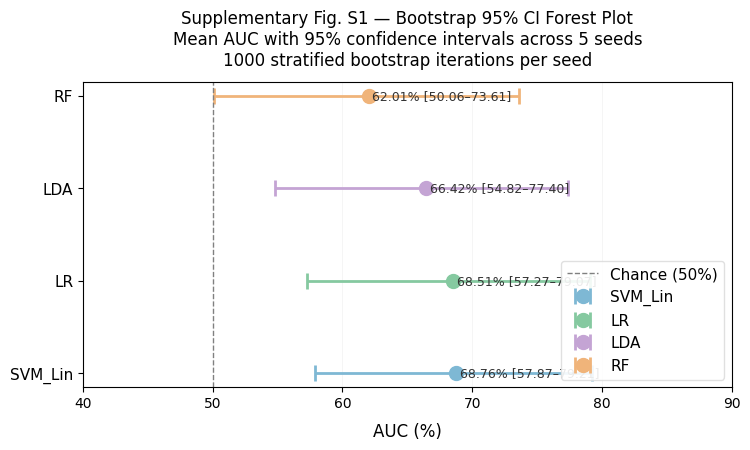

Saved → Fig_S1_bootstrap_CI


In [5]:
import matplotlib.pyplot as plt
import numpy as np

classifiers = ['SVM_Lin', 'LR', 'LDA', 'RF']
colors = ['#7EB8D4', '#85C9A0', '#C4A4D4', '#F0B47A']

mean_auc = [68.76, 68.51, 66.42, 62.01]
ci_lower = [57.87, 57.27, 54.82, 50.06]
ci_upper = [79.21, 79.07, 77.40, 73.61]

errors_lower = [m - l for m, l in zip(mean_auc, ci_lower)]
errors_upper = [u - m for m, u in zip(mean_auc, ci_upper)]

fig, ax = plt.subplots(figsize=(8, 5))

for i, (clf, color) in enumerate(zip(classifiers, colors)):
    ax.errorbar(
        mean_auc[i], i,
        xerr=[[errors_lower[i]], [errors_upper[i]]],
        fmt='o', color=color,
        markersize=10,
        capsize=6, capthick=2,
        linewidth=2.0,
        label=clf
    )
    ax.text(
        mean_auc[i] + 0.3, i,
        f"{mean_auc[i]:.2f}% [{ci_lower[i]:.2f}–{ci_upper[i]:.2f}]",
        va='center', fontsize=9, color='#333'
    )

ax.axvline(50, color='grey',
           linestyle='--', linewidth=1.0,
           label='Chance (50%)')
ax.set_yticks(range(len(classifiers)))
ax.set_yticklabels(classifiers, fontsize=11)
ax.set_xlabel('AUC (%)', fontsize=12, labelpad=8)
ax.set_title(
    'Supplementary Fig. S1 — Bootstrap 95% CI Forest Plot\n'
    'Mean AUC with 95% confidence intervals across 5 seeds\n'
    '1000 stratified bootstrap iterations per seed',
    fontsize=12, pad=12
)
ax.set_xlim(40, 90)
ax.grid(axis='x', linewidth=0.4, color='#eeeeee')
ax.legend(fontsize=11, loc='lower right',
          frameon=True, framealpha=0.9,
          edgecolor='#ddd')

plt.tight_layout(pad=2.5)
plt.savefig('Fig_S1_bootstrap_CI.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Fig_S1_bootstrap_CI.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved → Fig_S1_bootstrap_CI")

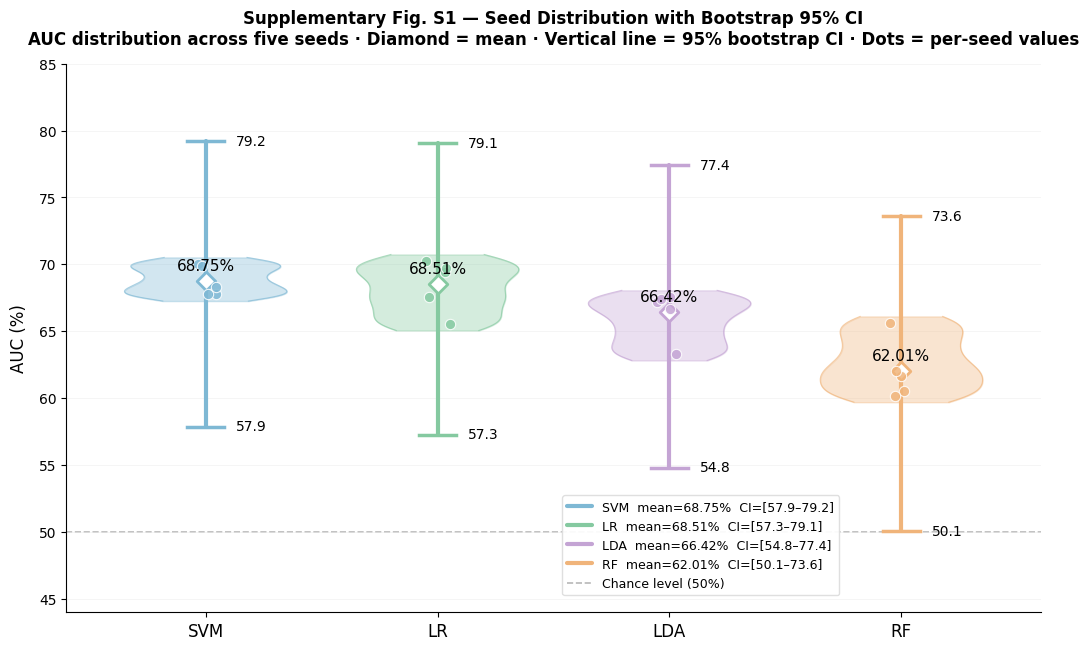

Saved → Fig_S1_violin_CI.pdf and .png


In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# ── Data — AUC values per seed (order: 42, 0, 1, 7, 99) ──────
auc_data = {
    'SVM': [67.80, 70.02, 67.76, 69.90, 68.29],
    'LR':      [70.24, 67.56, 65.56, 69.41, 69.76],
    'LDA':     [67.56, 67.17, 66.63, 67.41, 63.32],
    'RF':      [61.66, 62.05, 60.54, 60.20, 65.61],
}

# Bootstrap 95% CI (from your pipeline results)
ci_data = {
    'SVM':     (57.87, 79.21),
    'LR':      (57.27, 79.07),
    'LDA':     (54.82, 77.40),
    'RF':      (50.06, 73.61),
}

classifiers = ['SVM', 'LR', 'LDA', 'RF']
colors      = ['#7EB8D4', '#85C9A0', '#C4A4D4', '#F0B47A']
x_pos       = [1, 2, 3, 4]

# ── Figure ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

for i, (clf, color) in enumerate(zip(classifiers, colors)):
    vals     = np.array(auc_data[clf])
    mean_val = np.mean(vals)
    ci_low, ci_high = ci_data[clf]
    x        = x_pos[i]

    # ── Violin body ───────────────────────────────────────────
    # Need at least 5 points — use seed values + small jitter
    # to create a smooth distribution shape
    extended = np.concatenate([
        vals,
        np.linspace(vals.min() - 0.5, vals.max() + 0.5, 20)
    ])

    kde    = gaussian_kde(extended, bw_method=0.4)
    y_grid = np.linspace(extended.min(), extended.max(), 200)
    kde_vals = kde(y_grid)

    # Normalise width
    kde_vals = kde_vals / kde_vals.max() * 0.35

    ax.fill_betweenx(
        y_grid,
        x - kde_vals,
        x + kde_vals,
        alpha=0.35,
        color=color,
        zorder=2
    )
    ax.plot(
        x - kde_vals, y_grid,
        color=color, linewidth=0.8,
        alpha=0.6, zorder=2
    )
    ax.plot(
        x + kde_vals, y_grid,
        color=color, linewidth=0.8,
        alpha=0.6, zorder=2
    )

    # ── 95% CI vertical line ──────────────────────────────────
    ax.plot(
        [x, x], [ci_low, ci_high],
        color=color,
        linewidth=3.0,
        solid_capstyle='round',
        zorder=3,
        label=f"{clf}  mean={mean_val:.2f}%  CI=[{ci_low:.1f}–{ci_high:.1f}]"
    )

    # CI cap markers
    for cap_y in [ci_low, ci_high]:
        ax.plot(
            [x - 0.08, x + 0.08],
            [cap_y, cap_y],
            color=color,
            linewidth=2.5,
            zorder=4
        )

    # ── Mean diamond marker ───────────────────────────────────
    ax.scatter(
        x, mean_val,
        marker='D',
        s=90,
        color='white',
        edgecolors=color,
        linewidths=2.0,
        zorder=5
    )

    # ── Individual seed points ────────────────────────────────
    jitter = np.random.uniform(-0.06, 0.06, size=len(vals))
    ax.scatter(
        x + jitter, vals,
        color=color,
        s=55,
        alpha=0.85,
        edgecolors='white',
        linewidths=0.8,
        zorder=6
    )

    # ── Annotate mean value ───────────────────────────────────
    ax.text(
        x, mean_val + 0.6,
        f"{mean_val:.2f}%",
        ha='center',
        va='bottom',
        fontsize=11,
        # fontweight='bold',
        color='black',
        zorder=7
    )

    # ── Annotate CI bounds ────────────────────────────────────
    ax.text(
        x + 0.13, ci_high,
        f"{ci_high:.1f}",
        ha='left', va='center',
        fontsize=10, color= 'black'    )
    ax.text(
        x + 0.13, ci_low,
        f"{ci_low:.1f}",
        ha='left', va='center',
        fontsize=10, color='black'
    )

# ── Chance line ───────────────────────────────────────────────
ax.axhline(
    50,
    color='#999999',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7,
    label='Chance level (50%)',
    zorder=1
)

# ── Axes formatting ───────────────────────────────────────────
ax.set_xticks(x_pos)
ax.set_xticklabels(classifiers, fontsize=12)
ax.set_ylabel('AUC (%)', fontsize=12, labelpad=8)
ax.set_ylim(44, 85)
ax.set_xlim(0.4, 4.6)

ax.set_title(
    'Supplementary Fig. S1 — Seed Distribution with Bootstrap 95% CI\n'
    'AUC distribution across five seeds · Diamond = mean · '
    'Vertical line = 95% bootstrap CI · Dots = per-seed values',
    fontsize=12,
    fontweight='bold',
    pad=14
)

ax.legend(
    fontsize=9,
    frameon=True,
    framealpha=0.92,
    edgecolor='#dddddd',
    loc='lower right',
    bbox_to_anchor=(0.80, 0.02)  )

ax.grid(axis='y', linewidth=0.4, color='#eeeeee', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Save ──────────────────────────────────────────────────────
plt.tight_layout(pad=2.5)
plt.savefig('Fig_S1_violin_CI.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Fig_S1_violin_CI.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved → Fig_S1_violin_CI.pdf and .png")

Imports and style configured.
Data loaded.
Fig 1 saved → Fig1_classifier_performance.pdf / .png


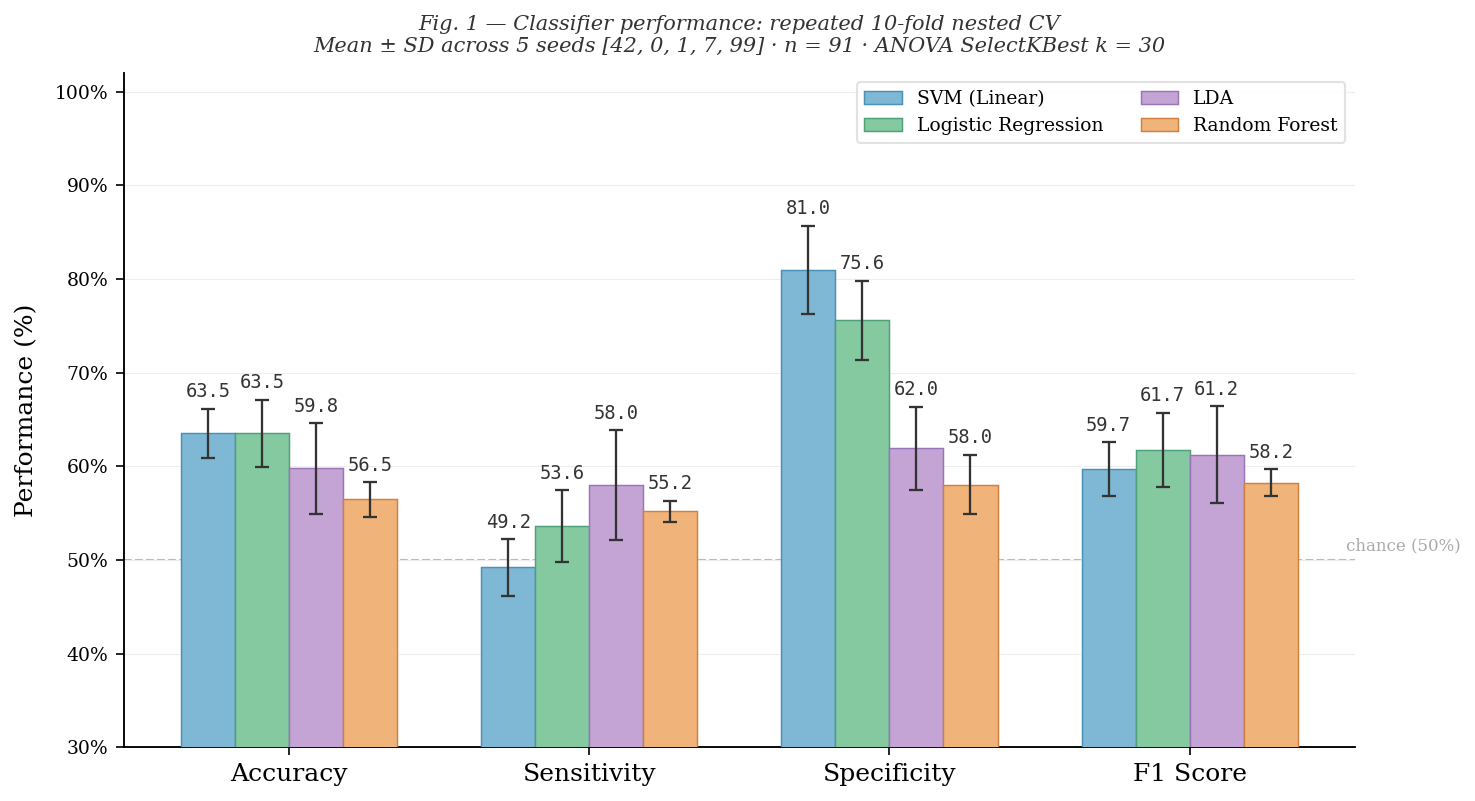

Fig 2 saved → Fig2_confusion_matrices.pdf / .png


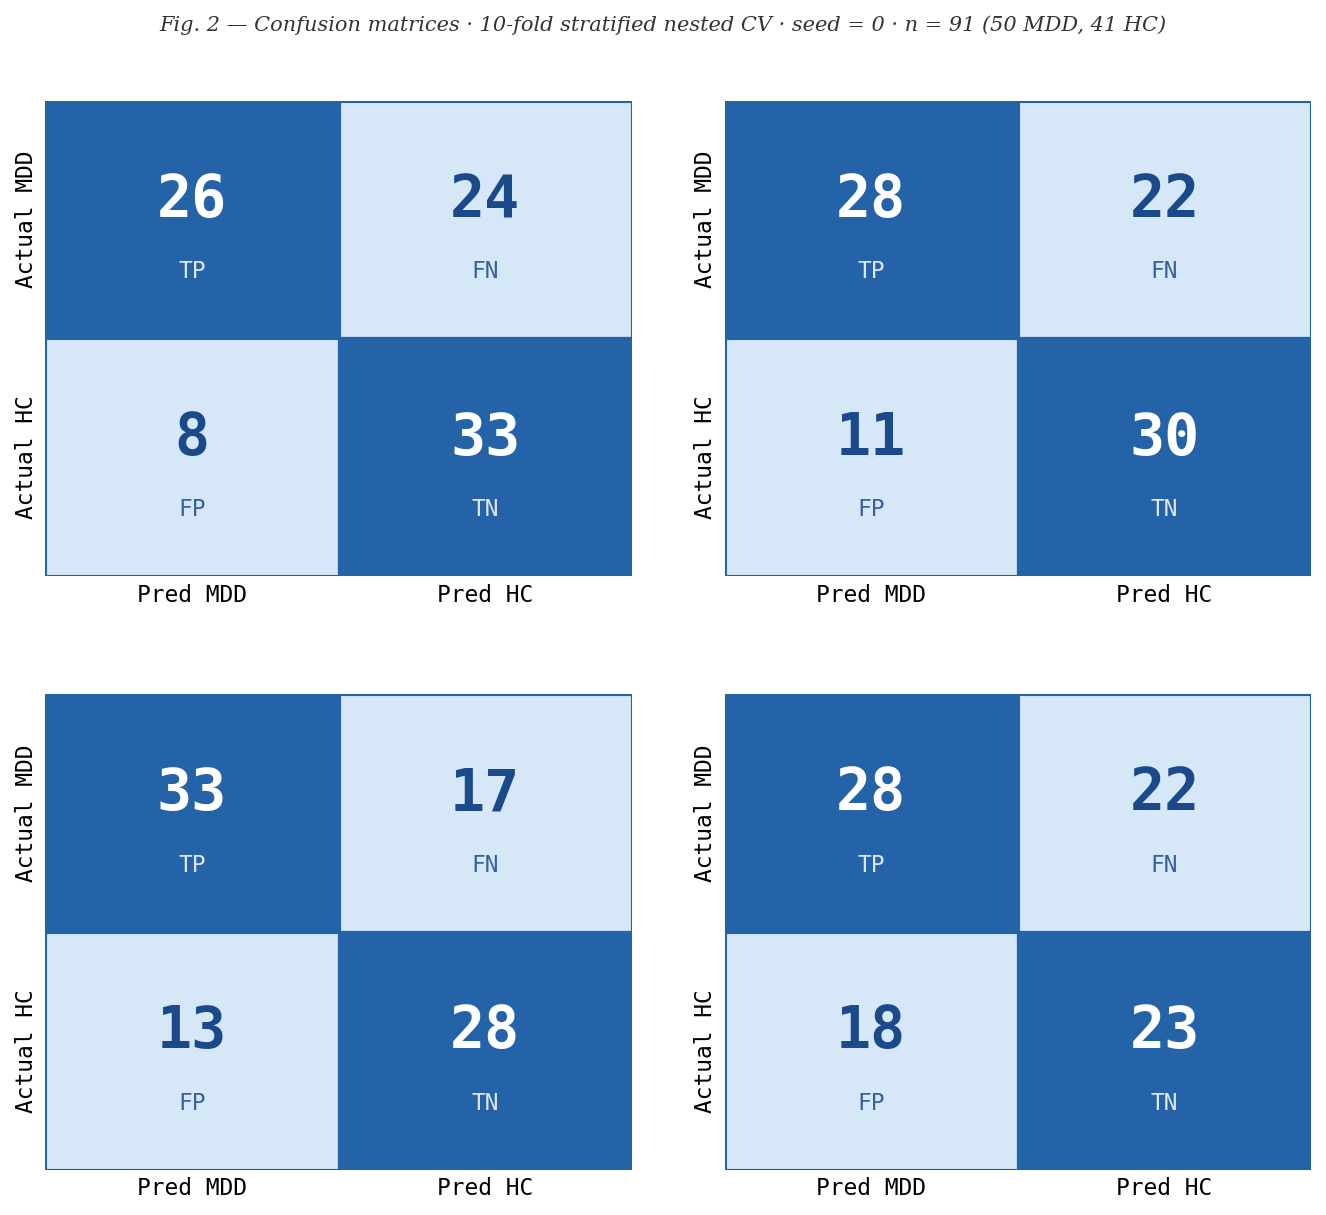

In [7]:
# =============================================================================
# =============================================================================
# Fig 1 — Grouped bar chart: Accuracy, Sensitivity, Specificity, F1
#          Mean ± SD across 5 seeds · 4 classifiers 
# Fig 2 — Confusion matrix panel: 2×2 grid for seed=0 only


import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

matplotlib.rcParams.update({
    'font.family':        'serif',
    'font.serif':         ['DejaVu Serif', 'Times New Roman', 'Georgia'],
    'font.size':          12,
    'axes.linewidth':     0.9,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'xtick.major.size':   4,
    'ytick.major.size':   4,
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
})

# ── Light colour palette ─────────────────────────────────────────────────────
CLF_COLORS = {
    'SVM (Linear)':        '#7EB8D4',   # soft blue
    'Logistic Regression': '#85C9A0',   # soft green
    'LDA':                 '#C4A4D4',   # soft purple
    'Random Forest':       '#F0B47A',   # soft orange
}

CLF_EDGE = {
    'SVM (Linear)':        '#4A91B8',
    'Logistic Regression': '#4EA07A',
    'LDA':                 '#9A74B8',
    'Random Forest':       '#D08040',
}

CLF_ORDER = ['SVM (Linear)', 'Logistic Regression', 'LDA', 'Random Forest']

print("Imports and style configured.")


# %%
# =============================================================================
# CELL 2 — DATA
# =============================================================================

# ── Fig 1: Mean ± SD across 5 seeds ─────────────────────────────────────────
metrics = ['Accuracy', 'Sensitivity', 'Specificity', 'F1 Score']

perf_data = {
    #                    Acc     Sens    Spec    F1
    'SVM (Linear)':
        {'mean': [63.52, 49.20,  80.98, 59.70],
         'sd':   [ 2.62,  3.03,   4.69,  2.85]},
    'Logistic Regression':
        {'mean': [63.52, 53.60,  75.61, 61.73],
         'sd':   [ 3.59,  3.85,   4.22,  3.98]},
    'LDA':
        {'mean': [59.78, 58.00,  61.95, 61.25],
         'sd':   [ 4.83,  5.83,   4.43,  5.15]},
    'Random Forest':
        {'mean': [56.48, 55.20,  58.05, 58.24],
         'sd':   [ 1.84,  1.10,   3.18,  1.44]},
}

# ── Fig 2: Confusion matrices — seed = 0 ─────────────────────────────────────
cm_data = {
    'SVM (Linear)':        {'tp': 26, 'tn': 33, 'fp':  8, 'fn': 24},
    'Logistic Regression': {'tp': 28, 'tn': 30, 'fp': 11, 'fn': 22},
    'LDA':                 {'tp': 33, 'tn': 28, 'fp': 13, 'fn': 17},
    'Random Forest':       {'tp': 28, 'tn': 23, 'fp': 18, 'fn': 22},
}

print("Data loaded.")


# %%
# =============================================================================
# CELL 3 — FIGURE 1: GROUPED BAR CHART
# =============================================================================

n_metrics = len(metrics)
n_clfs    = len(CLF_ORDER)
x         = np.arange(n_metrics)

# Bar width and offset calculations
total_width = 0.72
bar_w       = total_width / n_clfs
offsets     = np.linspace(-(total_width - bar_w) / 2,
                           (total_width - bar_w) / 2,
                           n_clfs)

fig1, ax1 = plt.subplots(figsize=(10, 5.5))

for ci, clf in enumerate(CLF_ORDER):
    means = perf_data[clf]['mean']
    sds   = perf_data[clf]['sd']
    xpos  = x + offsets[ci]

    bars = ax1.bar(
        xpos, means,
        width=bar_w,
        color=CLF_COLORS[clf],
        edgecolor=CLF_EDGE[clf],
        linewidth=0.7,
        label=clf,
        zorder=3,
        capsize=0,
    )

    # Error bars
    ax1.errorbar(
        xpos, means,
        yerr=sds,
        fmt='none',
        ecolor='#333333',
        elinewidth=1.1,
        capsize=3.5,
        capthick=1.1,
        zorder=4,
    )

    # Value labels on top of each bar
    for xp, mean, sd in zip(xpos, means, sds):
        ax1.text(
            xp, mean + sd + 0.8,
            f'{mean:.1f}',
            ha='center', va='bottom',
            fontsize=9, color='#333',
            fontfamily='monospace'
        )

# Chance line
ax1.axhline(50, color='#bbbbbb', linestyle='--',
            linewidth=1.0, zorder=1, label='_nolegend_')
ax1.text(n_metrics - 0.48, 50.6, 'chance (50%)',
         fontsize=8, color='#aaaaaa', va='bottom')

# Axes
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=12)
ax1.set_ylabel('Performance (%)', fontsize=12, labelpad=8)
ax1.set_ylim(30, 102)
ax1.set_yticks(np.arange(30, 101, 10))
ax1.set_yticklabels([f'{v}%' for v in np.arange(30, 101, 10)], fontsize=9)
ax1.set_xlim(-0.55, n_metrics - 0.45)
ax1.grid(axis='y', linewidth=0.5, color='#eeeeee', zorder=0)

# Legend
legend_handles = [
    mpatches.Patch(facecolor=CLF_COLORS[clf],
                   edgecolor=CLF_EDGE[clf],
                   linewidth=0.7,
                   label=clf)
    for clf in CLF_ORDER
]
ax1.legend(
    handles=legend_handles,
    fontsize=9, frameon=True,
    framealpha=0.92, edgecolor='#e0e0e0',
    loc='upper right',
    ncol=2
)

ax1.set_title(
    'Fig. 1 — Classifier performance: repeated 10-fold nested CV\n'
    'Mean ± SD across 5 seeds [42, 0, 1, 7, 99] · n = 91 · ANOVA SelectKBest k = 30',
    fontsize=10, pad=10, color='#333', fontstyle='italic'
)

plt.tight_layout()
plt.savefig('Fig1_classifier_performance.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Fig1_classifier_performance.png', dpi=300, bbox_inches='tight')
print("Fig 1 saved → Fig1_classifier_performance.pdf / .png")
plt.show()


# %%
# =============================================================================
# CELL 4 — FIGURE 2: CONFUSION MATRIX PANEL (2 × 2)
# =============================================================================

# Blue palette
BLUE_DARK  = '#2563A8'   # diagonal (correct) — deep blue
BLUE_LIGHT = '#D6E8F7'   # off-diagonal (errors) — very light blue
TEXT_LIGHT = '#FFFFFF'   # text on dark cells
TEXT_DARK  = '#1A4A8A'   # text on light cells
BORDER_COL = '#2563A8'

fig2, axes2 = plt.subplots(2, 2, figsize=(9, 8))
axes2_flat  = axes2.flatten()

for idx, clf in enumerate(CLF_ORDER):
    ax  = axes2_flat[idx]
    cm  = cm_data[clf]
    col = CLF_COLORS[clf]

    # Build 2×2 matrix: [[TP, FN], [FP, TN]]
    matrix      = np.array([[cm['tp'], cm['fn']],
                             [cm['fp'], cm['tn']]])
    cell_labels = [['TP', 'FN'], ['FP', 'TN']]
    row_labels  = ['Actual MDD', 'Actual HC']
    col_labels  = ['Pred MDD',   'Pred HC']

    # Draw cells
    for r in range(2):
        for c in range(2):
            is_diag  = (r == c)
            bg_color = BLUE_DARK  if is_diag else BLUE_LIGHT
            fg_color = TEXT_LIGHT if is_diag else TEXT_DARK

            rect = plt.Rectangle(
                [c, 1 - r], 1, 1,
                facecolor=bg_color,
                edgecolor=BORDER_COL,
                linewidth=1.5,
                transform=ax.transData
            )
            ax.add_patch(rect)

            # Count (large)
            ax.text(
                c + 0.5, 1 - r + 0.58,
                str(matrix[r, c]),
                ha='center', va='center',
                fontsize=28, fontweight='bold',
                color=fg_color,
                fontfamily='monospace'
            )

            # Label (small, below count)
            ax.text(
                c + 0.5, 1 - r + 0.28,
                cell_labels[r][c],
                ha='center', va='center',
                fontsize=11, color=fg_color,
                fontfamily='monospace',
                alpha=0.85
            )

    # Axes setup
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(col_labels, fontsize=11, fontfamily='monospace')
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(row_labels[::-1], fontsize=11,
                       fontfamily='monospace', rotation=90,
                       va='center')
    ax.tick_params(length=0)

    # Spines off
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Classifier title with colour dot
    # ax.set_title(
    #     clf,
    #     fontsize=11, pad=10,
    #     fontfamily='monospace',
    #     fontweight='bold',
    #     color=BLUE_DARK
    # )

    # # Metrics below each matrix
    # acc  = (cm['tp'] + cm['tn']) / 91 * 100
    # sens = cm['tp'] / 50 * 100
    # spec = cm['tn'] / 41 * 100
    # ax.text(
    #     1.0, -0.12,
    #     f'Acc={acc:.1f}%   Sens={sens:.1f}%   Spec={spec:.1f}%',
    #     ha='center', va='top',
    #     fontsize=8.5, color='#555',
    #     fontfamily='monospace',
    #     transform=ax.transData
    # )

fig2.suptitle(
    'Fig. 2 — Confusion matrices · 10-fold stratified nested CV · seed = 0 · n = 91 (50 MDD, 41 HC)',
    fontsize=10, y=1.01, color='#333', fontstyle='italic'
)

plt.tight_layout(h_pad=3.5, w_pad=2.5)
plt.savefig('Fig2_confusion_matrices.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Fig2_confusion_matrices.png', dpi=300, bbox_inches='tight')
print("Fig 2 saved → Fig2_confusion_matrices.pdf / .png")
plt.show()

In [11]:
# =============================================================================
# EEG-MDD BIOMARKER VALIDATION PIPELINE — FINAL RF-SHAP VERSION

# =============================================================================
# CELL 1 — IMPORTS
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

from scipy.stats import shapiro, mannwhitneyu, spearmanr
from statsmodels.stats.multitest import multipletests

SEED = 42
TOP_N = 20
CORR_THRESHOLD = 0.85

MAIN_CLASSIFIERS = ["RF", "SVM_Lin", "LR", "LDA"]
SUPPLEMENTARY_CLASSIFIERS = ["XGBoost"]

HC_LABEL = 0
MDD_LABEL = 1

print("=" * 80)
print("FINAL RF-SHAP BIOMARKER VALIDATION PIPELINE")
print("=" * 80)
print(f"Main classifiers         : {MAIN_CLASSIFIERS}")
print(f"Supplementary classifier : {SUPPLEMENTARY_CLASSIFIERS}")
print(f"Top SHAP features        : {TOP_N}")
print("=" * 80)


# %%
# =============================================================================
# CELL 2 — GET CONSENSUS k FROM REPEATED NESTED CV
# =============================================================================

def get_consensus_k_from_nested_results(all_results, classifiers_for_k=None):
    if classifiers_for_k is None:
        classifiers_for_k = MAIN_CLASSIFIERS

    all_ks = []

    for res in all_results:
        for clf in classifiers_for_k:
            if clf in res["best_k_log"]:
                all_ks.extend(res["best_k_log"][clf])

    consensus_k = Counter(all_ks).most_common(1)[0][0]
    return consensus_k, Counter(all_ks)


consensus_k, k_counter = get_consensus_k_from_nested_results(
    all_nested_results,
    classifiers_for_k=MAIN_CLASSIFIERS
)

print("=" * 80)
print("CONSENSUS k FROM REPEATED NESTED CV")
print("=" * 80)
print(f"Consensus k: {consensus_k}")
print("k distribution:")
for k, count in sorted(k_counter.items()):
    print(f"k={k:<3} count={count}")
print("=" * 80)


# %%
# =============================================================================
# CELL 3 — FEATURE METADATA MAPPING FOR EXISTING 314 CSV FEATURES
# =============================================================================

ELECTRODE_ORDER = [
    'Fp1', 'F3', 'C3', 'P3', 'O1',
    'F7', 'T3', 'T5',
    'Fp2', 'F4', 'C4', 'P4', 'O2',
    'F8', 'T4', 'T6',
    'Fz', 'Cz', 'Pz'
]

FEATURE_TYPE_LIST = [
    'Alpha_Band_psd_mean',
    'Beta_Band_psd_mean',
    'Gamma_Band_psd_mean',
    'Theta_Band_psd_mean',
    'Delta_Band_psd_mean',
    'Alpha_Band_psd_variance',
    'Beta_Band_psd_variance',
    'Gamma_Band_psd_variance',
    'Theta_Band_psd_variance',
    'Delta_Band_psd_variance',
    'Fractal_Dimension',
    'Wavelet_Energy',
    'Spectral_Entropy',
    'Hjorth_Activity',
    'Hjorth_Mobility',
    'Hjorth_Complexity'
]

EXTRA_FEATURE_INFO = {
    'Alpha_Asymmetry_Fp2_minus_Fp1': {
        'Electrode': 'Fp2-Fp1',
        'Region': 'Prefrontal',
        'Lobe': 'Frontal',
        'Hemisphere': 'Right-Left',
        'Scalp': 'Prefrontal right-left asymmetry',
        'Feature_Type': 'Alpha_Asymmetry'
    },
    'Alpha_Asymmetry_F4_minus_F3': {
        'Electrode': 'F4-F3',
        'Region': 'Frontal',
        'Lobe': 'Frontal',
        'Hemisphere': 'Right-Left',
        'Scalp': 'Frontal right-left asymmetry',
        'Feature_Type': 'Alpha_Asymmetry'
    },
    'Alpha_Asymmetry_F8_minus_F7': {
        'Electrode': 'F8-F7',
        'Region': 'Fronto-temporal',
        'Lobe': 'Frontal',
        'Hemisphere': 'Right-Left',
        'Scalp': 'Fronto-temporal right-left asymmetry',
        'Feature_Type': 'Alpha_Asymmetry'
    },
    'Theta_Alpha_Ratio_Fp1': {
        'Electrode': 'Fp1',
        'Region': 'Prefrontal',
        'Lobe': 'Frontal',
        'Hemisphere': 'Left',
        'Scalp': 'Left prefrontal scalp',
        'Feature_Type': 'Theta_Alpha_Ratio'
    },
    'Theta_Alpha_Ratio_F3': {
        'Electrode': 'F3',
        'Region': 'Frontal',
        'Lobe': 'Frontal',
        'Hemisphere': 'Left',
        'Scalp': 'Left frontal scalp',
        'Feature_Type': 'Theta_Alpha_Ratio'
    },
    'Theta_Alpha_Ratio_F4': {
        'Electrode': 'F4',
        'Region': 'Frontal',
        'Lobe': 'Frontal',
        'Hemisphere': 'Right',
        'Scalp': 'Right frontal scalp',
        'Feature_Type': 'Theta_Alpha_Ratio'
    },
    'Theta_Alpha_Ratio_Fp2': {
        'Electrode': 'Fp2',
        'Region': 'Prefrontal',
        'Lobe': 'Frontal',
        'Hemisphere': 'Right',
        'Scalp': 'Right prefrontal scalp',
        'Feature_Type': 'Theta_Alpha_Ratio'
    },
    'Theta_Alpha_Ratio_F7': {
        'Electrode': 'F7',
        'Region': 'Fronto-temporal',
        'Lobe': 'Frontal',
        'Hemisphere': 'Left',
        'Scalp': 'Left fronto-temporal scalp',
        'Feature_Type': 'Theta_Alpha_Ratio'
    },
    'Theta_Alpha_Ratio_F8': {
        'Electrode': 'F8',
        'Region': 'Fronto-temporal',
        'Lobe': 'Frontal',
        'Hemisphere': 'Right',
        'Scalp': 'Right fronto-temporal scalp',
        'Feature_Type': 'Theta_Alpha_Ratio'
    },
    'Theta_Alpha_Ratio_Fz': {
        'Electrode': 'Fz',
        'Region': 'Frontal midline',
        'Lobe': 'Frontal',
        'Hemisphere': 'Midline',
        'Scalp': 'Frontal midline scalp',
        'Feature_Type': 'Theta_Alpha_Ratio'
    }
}

ELECTRODE_META = {
    'Fp1': {'Region':'Prefrontal', 'Lobe':'Frontal', 'Hemisphere':'Left', 'Scalp':'Left prefrontal scalp'},
    'Fp2': {'Region':'Prefrontal', 'Lobe':'Frontal', 'Hemisphere':'Right', 'Scalp':'Right prefrontal scalp'},
    'F3':  {'Region':'Frontal', 'Lobe':'Frontal', 'Hemisphere':'Left', 'Scalp':'Left frontal scalp'},
    'F4':  {'Region':'Frontal', 'Lobe':'Frontal', 'Hemisphere':'Right', 'Scalp':'Right frontal scalp'},
    'F7':  {'Region':'Fronto-temporal', 'Lobe':'Frontal', 'Hemisphere':'Left', 'Scalp':'Left fronto-temporal scalp'},
    'F8':  {'Region':'Fronto-temporal', 'Lobe':'Frontal', 'Hemisphere':'Right', 'Scalp':'Right fronto-temporal scalp'},
    'Fz':  {'Region':'Frontal midline', 'Lobe':'Frontal', 'Hemisphere':'Midline', 'Scalp':'Frontal midline scalp'},
    'C3':  {'Region':'Central', 'Lobe':'Parietal', 'Hemisphere':'Left', 'Scalp':'Left central scalp'},
    'C4':  {'Region':'Central', 'Lobe':'Parietal', 'Hemisphere':'Right', 'Scalp':'Right central scalp'},
    'Cz':  {'Region':'Central midline', 'Lobe':'Parietal', 'Hemisphere':'Midline', 'Scalp':'Central vertex'},
    'P3':  {'Region':'Parietal', 'Lobe':'Parietal', 'Hemisphere':'Left', 'Scalp':'Left parietal scalp'},
    'P4':  {'Region':'Parietal', 'Lobe':'Parietal', 'Hemisphere':'Right', 'Scalp':'Right parietal scalp'},
    'Pz':  {'Region':'Parietal midline', 'Lobe':'Parietal', 'Hemisphere':'Midline', 'Scalp':'Parietal midline scalp'},
    'O1':  {'Region':'Occipital', 'Lobe':'Occipital', 'Hemisphere':'Left', 'Scalp':'Left occipital scalp'},
    'O2':  {'Region':'Occipital', 'Lobe':'Occipital', 'Hemisphere':'Right', 'Scalp':'Right occipital scalp'},
    'T3':  {'Region':'Temporal', 'Lobe':'Temporal', 'Hemisphere':'Left', 'Scalp':'Left mid-temporal scalp'},
    'T4':  {'Region':'Temporal', 'Lobe':'Temporal', 'Hemisphere':'Right', 'Scalp':'Right mid-temporal scalp'},
    'T5':  {'Region':'Temporo-parietal', 'Lobe':'Temporal', 'Hemisphere':'Left', 'Scalp':'Left posterior temporal scalp'},
    'T6':  {'Region':'Temporo-parietal', 'Lobe':'Temporal', 'Hemisphere':'Right', 'Scalp':'Right posterior temporal scalp'},
}

feature_metadata_rows = []

for i, feat in enumerate(feature_names):

    if i < 304:
        elec_idx = i // 16
        pos_idx = i % 16

        electrode = ELECTRODE_ORDER[elec_idx]
        feature_type = FEATURE_TYPE_LIST[pos_idx]
        meta = ELECTRODE_META[electrode]

        feature_metadata_rows.append({
            "Feature": feat,
            "CSV_Feature_Index": i,
            "Electrode": electrode,
            "Region": meta["Region"],
            "Lobe": meta["Lobe"],
            "Hemisphere": meta["Hemisphere"],
            "Scalp": meta["Scalp"],
            "Feature_Type": feature_type
        })

    else:
        info = EXTRA_FEATURE_INFO.get(feat, {
            "Electrode": "Unknown",
            "Region": "Unknown",
            "Lobe": "Unknown",
            "Hemisphere": "Unknown",
            "Scalp": "Unknown",
            "Feature_Type": "Unknown"
        })

        feature_metadata_rows.append({
            "Feature": feat,
            "CSV_Feature_Index": i,
            "Electrode": info["Electrode"],
            "Region": info["Region"],
            "Lobe": info["Lobe"],
            "Hemisphere": info["Hemisphere"],
            "Scalp": info["Scalp"],
            "Feature_Type": info["Feature_Type"]
        })

feature_metadata_df = pd.DataFrame(feature_metadata_rows)

print("=" * 120)
print("UNIFIED FEATURE METADATA TABLE CREATED FOR ALL EXISTING CSV FEATURES")
print("=" * 120)
print(feature_metadata_df.tail(15))
print("=" * 120)
print("Total features mapped:", len(feature_metadata_df))


# %%
# =============================================================================
# CELL 4 — TRAIN FINAL RF MODEL FOR SHAP
# =============================================================================

final_rf_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("sel", SelectKBest(score_func=f_classif, k=consensus_k)),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        max_features="sqrt",
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    ))
])

final_rf_pipe.fit(X, Y)

selector = final_rf_pipe.named_steps["sel"]
scaler = final_rf_pipe.named_steps["scaler"]
rf_clf = final_rf_pipe.named_steps["clf"]

selected_idx = selector.get_support(indices=True)
selected_features = [feature_names[i] for i in selected_idx]

X_scaled = scaler.transform(X)
X_selected = selector.transform(X_scaled)

X_selected_df = pd.DataFrame(X_selected, columns=selected_features)

print("=" * 80)
print("FINAL RF MODEL FOR SHAP")
print("=" * 80)
print(f"Selected k             : {consensus_k}")
print(f"Selected feature count : {len(selected_features)}")
for i, feat in enumerate(selected_features, 1):
    print(f"{i:02d}. {feat}")
print("=" * 80)


# %%
# =============================================================================
# CELL 5 — RF-SHAP VALUES
# =============================================================================

explainer = shap.TreeExplainer(rf_clf)

shap_values = explainer.shap_values(X_selected_df)

# Handle SHAP output shape
if isinstance(shap_values, list):

    shap_values_for_mdd = shap_values[1]

elif isinstance(shap_values, np.ndarray):

    if shap_values.ndim == 3:
        shap_values_for_mdd = shap_values[:, :, 1]
    else:
        shap_values_for_mdd = shap_values

else:
    raise ValueError("Unexpected SHAP output format")

print("SHAP shape:", shap_values_for_mdd.shape)

# Mean absolute SHAP
mean_abs_shap = np.abs(shap_values_for_mdd).mean(axis=0)
mean_abs_shap = np.ravel(mean_abs_shap)

# Mean signed SHAP
mean_signed_shap = shap_values_for_mdd.mean(axis=0)
mean_signed_shap = np.ravel(mean_signed_shap)

# CREATE DATAFRAME
shap_ranking_df = pd.DataFrame({
    "Feature": selected_features,
    "Mean_abs_SHAP": mean_abs_shap,
    "Mean_signed_SHAP": mean_signed_shap
})

# SORT
shap_ranking_df = shap_ranking_df.sort_values(
    "Mean_abs_SHAP",
    ascending=False
).reset_index(drop=True)

# Add rank
shap_ranking_df["SHAP_Rank"] = np.arange(
    1,
    len(shap_ranking_df) + 1
)

print("=" * 100)
print(f"TOP {TOP_N} RF-SHAP FEATURES")
print("=" * 100)

print(
    shap_ranking_df.head(TOP_N).to_string(index=False)
)

print("=" * 100)

FINAL RF-SHAP BIOMARKER VALIDATION PIPELINE
Main classifiers         : ['RF', 'SVM_Lin', 'LR', 'LDA']
Supplementary classifier : ['XGBoost']
Top SHAP features        : 20
CONSENSUS k FROM REPEATED NESTED CV
Consensus k: 30
k distribution:
k=10  count=33
k=15  count=24
k=20  count=41
k=25  count=43
k=30  count=59
UNIFIED FEATURE METADATA TABLE CREATED FOR ALL EXISTING CSV FEATURES
                           Feature  CSV_Feature_Index Electrode  \
299              Wavelet_Energy_18                299        Pz   
300            Spectral_Entropy_18                300        Pz   
301             Hjorth_Activity_18                301        Pz   
302             Hjorth_Mobility_18                302        Pz   
303           Hjorth_Complexity_18                303        Pz   
304  Alpha_Asymmetry_Fp2_minus_Fp1                304   Fp2-Fp1   
305    Alpha_Asymmetry_F4_minus_F3                305     F4-F3   
306    Alpha_Asymmetry_F8_minus_F7                306     F8-F7   
307          T

EEG-MDD RF-SHAP BIOMARKER PIPELINE — CLEAN SEPARATED FIGURES VERSION
Output directory : biomarker_figures/
Top SHAP features: 20
Corr threshold   : 0.85
DATA CHECK
X shape        : (91, 314)
Y shape        : (91,)
Feature count  : 314
MDD (label=1)  : 50
HC  (label=0)  : 41

Consensus k = 30
k distribution:
  k=10  → 33 selections
  k=15  → 24 selections
  k=20  → 41 selections
  k=25  → 43 selections
  k=30  → 59 selections

Feature metadata mapped: 314 features

Final RF model: k=30 features selected
SHAP computed. Top 20 features identified.

Generating Fig 1 — SHAP beeswarm summary plot...
  Saved → biomarker_figures\Fig1_SHAP_beeswarm_summary.pdf
  Saved → biomarker_figures\Fig1_SHAP_beeswarm_summary.png


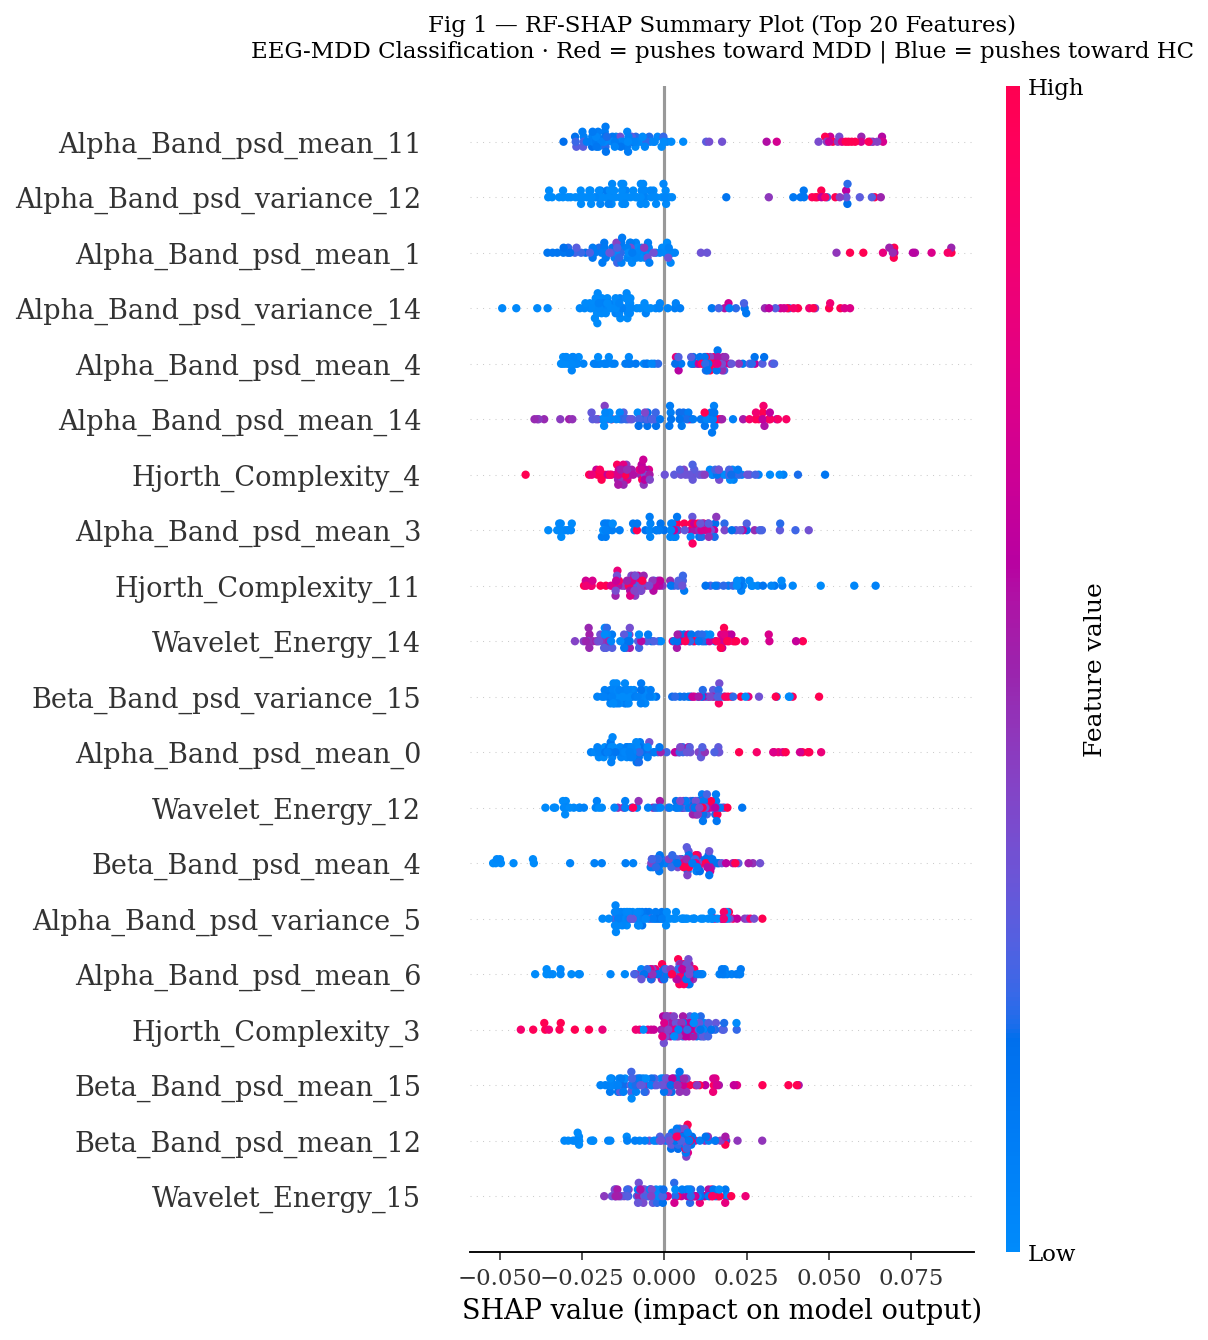


Generating Fig 2 — SHAP bar plot...
  Saved → biomarker_figures\Fig2_SHAP_bar_plot_top20.pdf
  Saved → biomarker_figures\Fig2_SHAP_bar_plot_top20.png


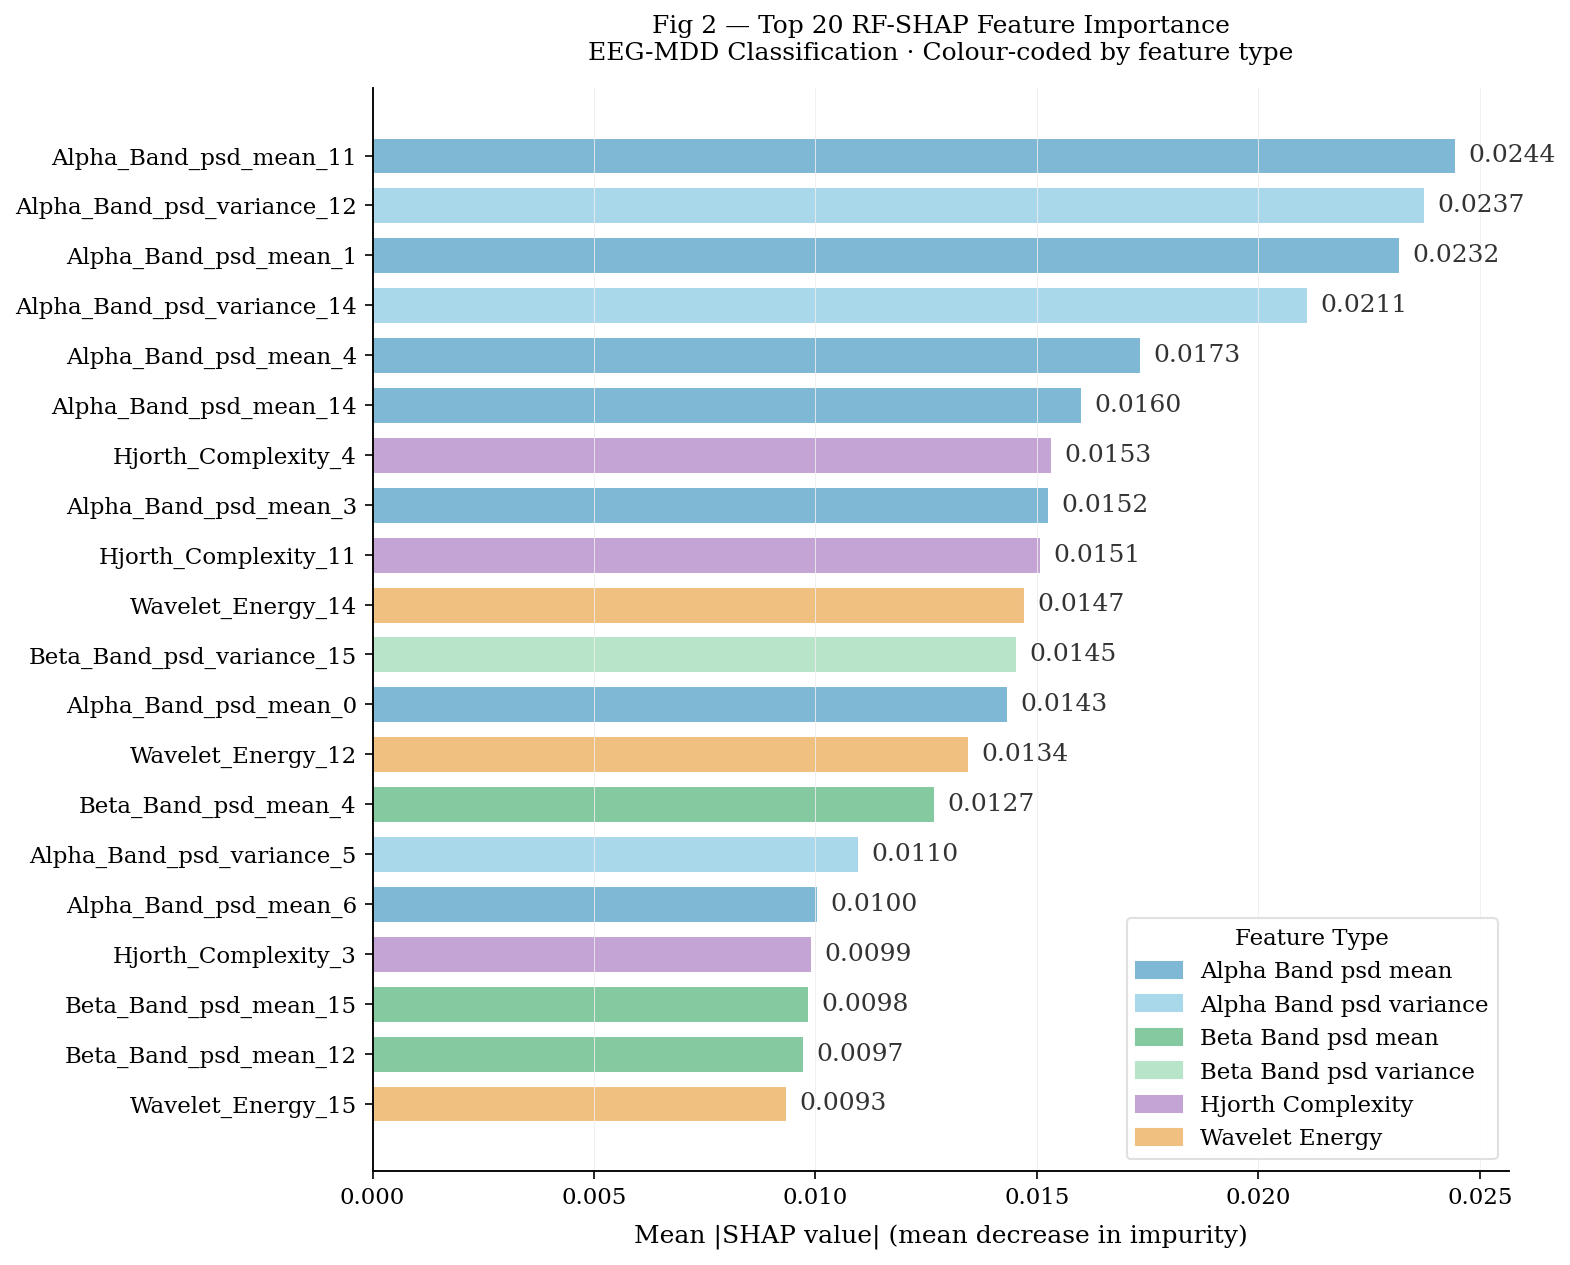


Generating Fig 3 — ROC curves...
  Saved → biomarker_figures\Fig3_ROC_curves_main_classifiers.pdf
  Saved → biomarker_figures\Fig3_ROC_curves_main_classifiers.png


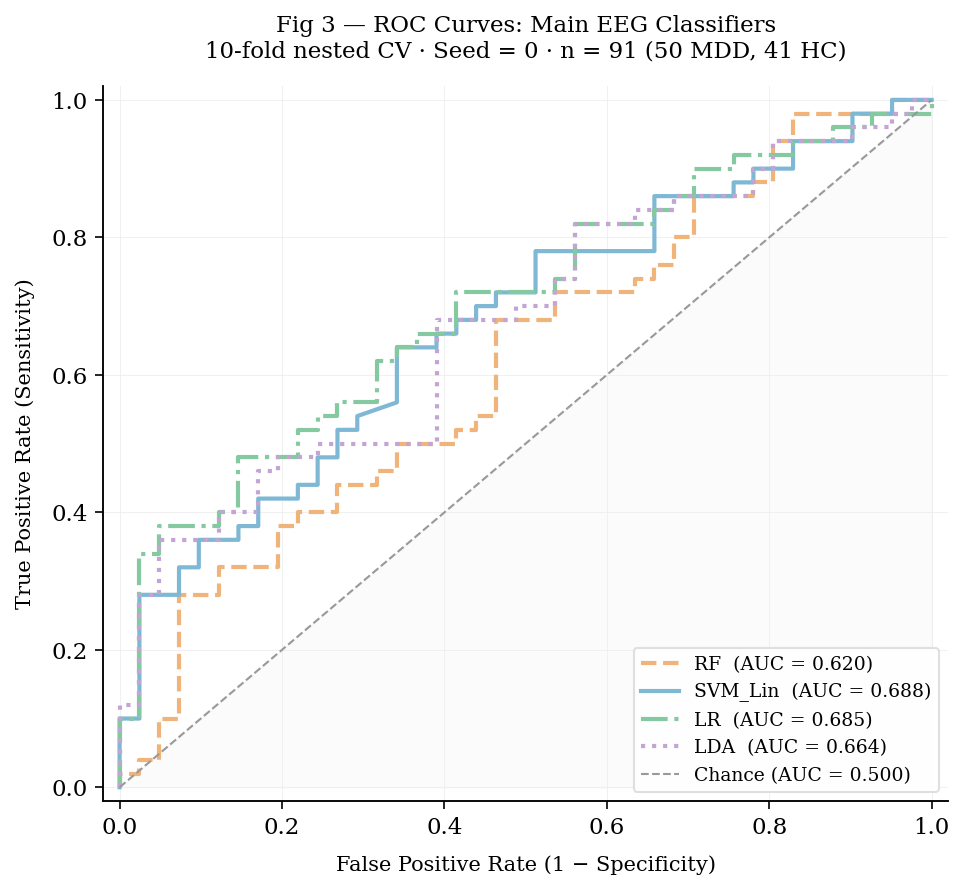


Running statistical validation pipeline...
Candidate biomarkers: 20/20
Non-normal features : 17/20

Non-redundant biomarkers : 15
Removed as redundant     : 5

Generating Fig 4 — Boxplots of non-redundant biomarkers...
  Saved → biomarker_figures\Fig4_1_boxplot_Alpha_Band_psd_mean_11.pdf
  Saved → biomarker_figures\Fig4_1_boxplot_Alpha_Band_psd_mean_11.png


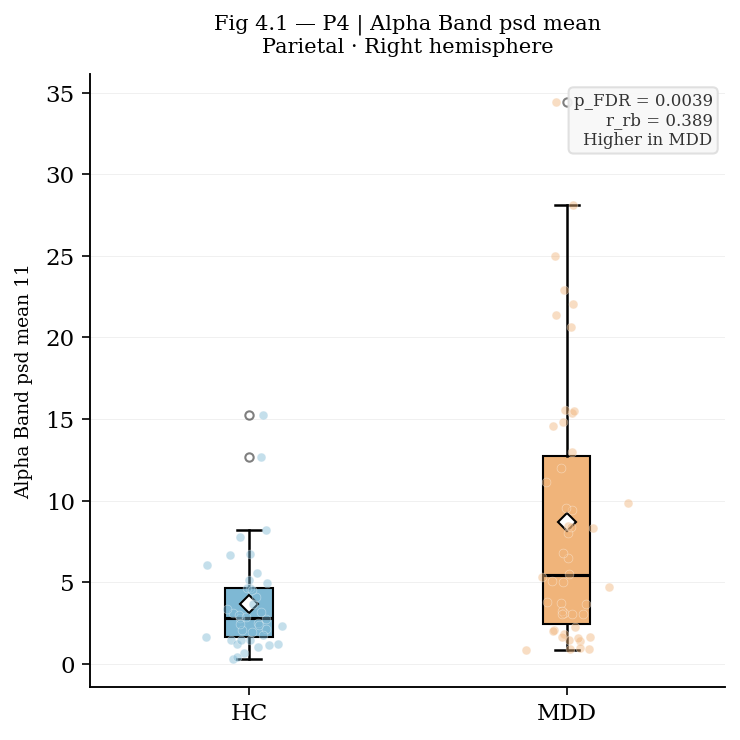

  Saved → biomarker_figures\Fig4_2_boxplot_Alpha_Band_psd_variance_12.pdf
  Saved → biomarker_figures\Fig4_2_boxplot_Alpha_Band_psd_variance_12.png


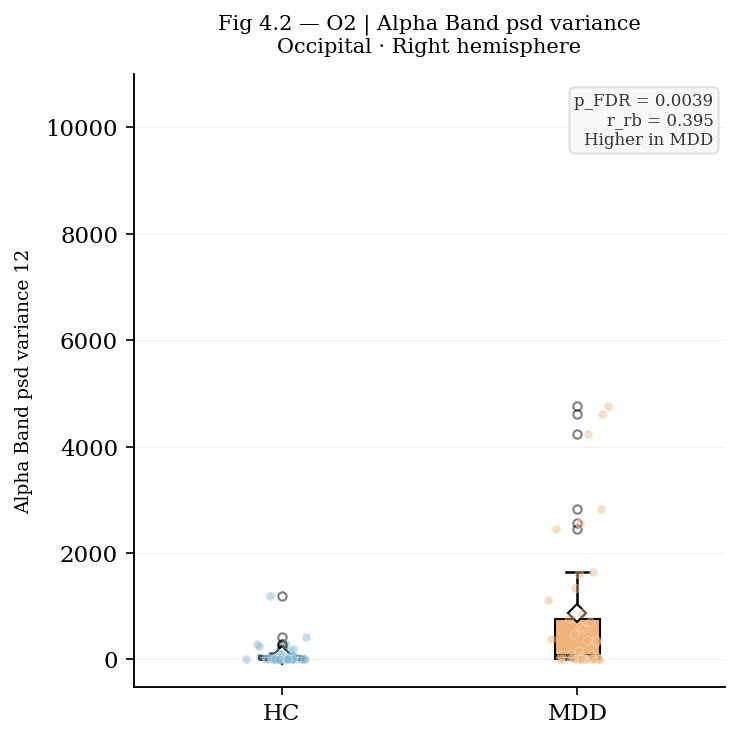

  Saved → biomarker_figures\Fig4_3_boxplot_Alpha_Band_psd_mean_1.pdf
  Saved → biomarker_figures\Fig4_3_boxplot_Alpha_Band_psd_mean_1.png


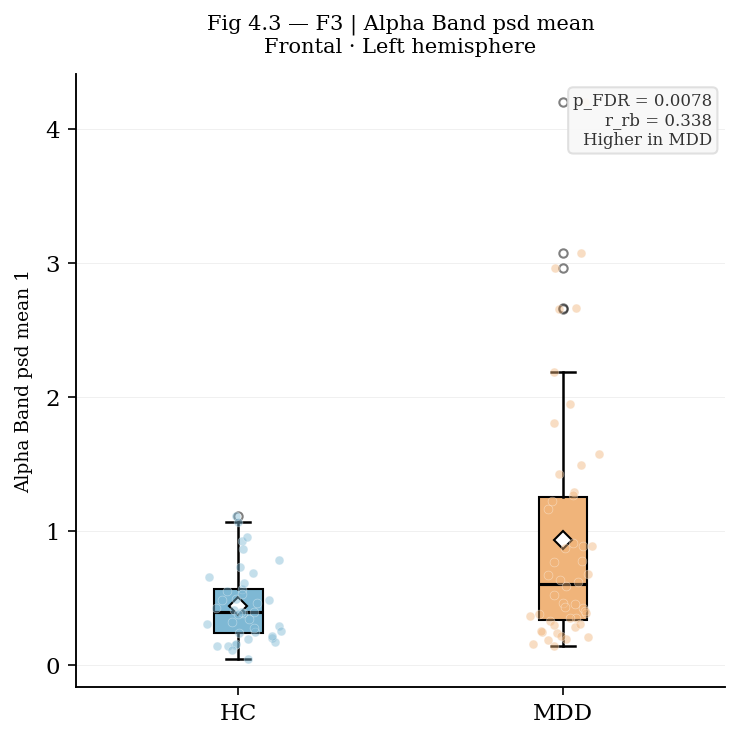

  Saved → biomarker_figures\Fig4_4_boxplot_Alpha_Band_psd_variance_14.pdf
  Saved → biomarker_figures\Fig4_4_boxplot_Alpha_Band_psd_variance_14.png


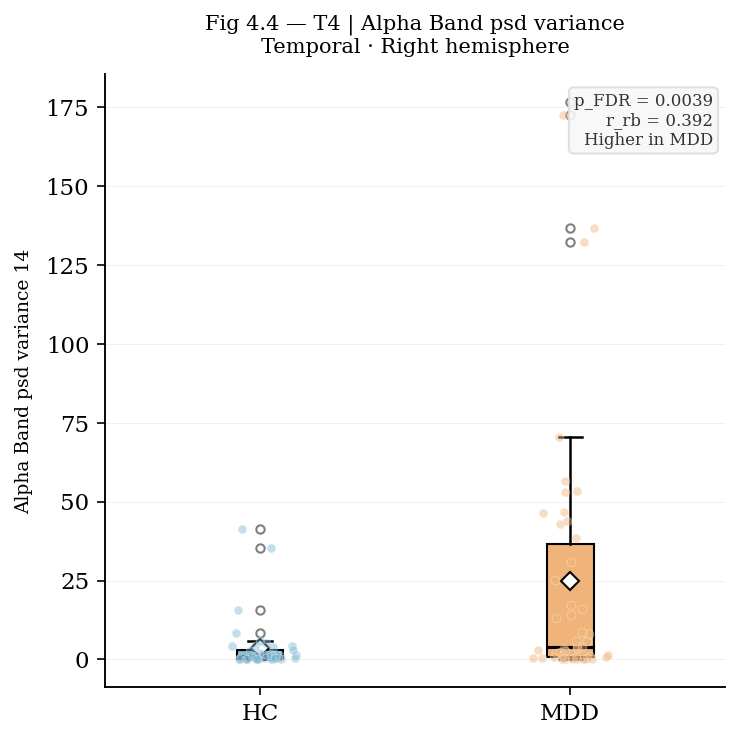

  Saved → biomarker_figures\Fig4_5_boxplot_Alpha_Band_psd_mean_4.pdf
  Saved → biomarker_figures\Fig4_5_boxplot_Alpha_Band_psd_mean_4.png


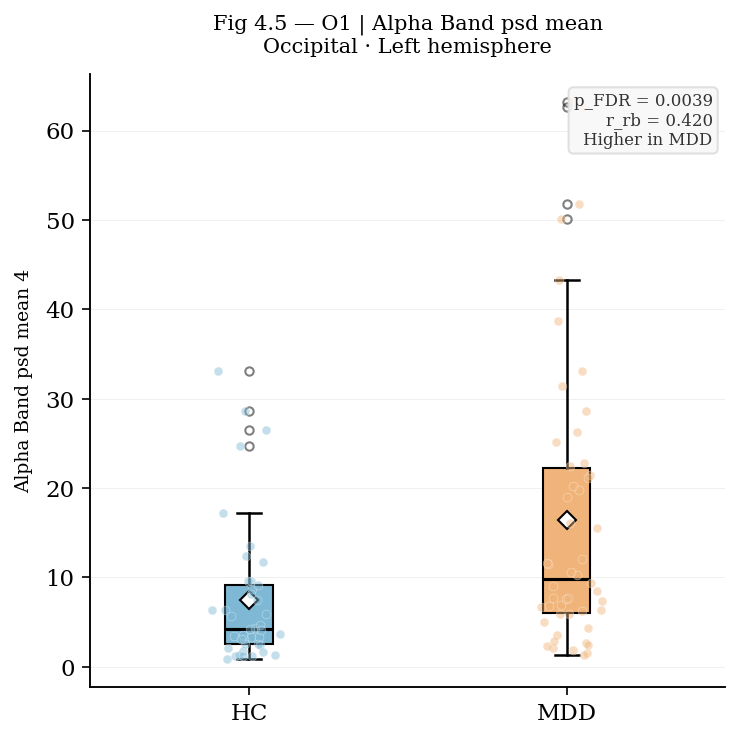

  Saved → biomarker_figures\Fig4_6_boxplot_Hjorth_Complexity_4.pdf
  Saved → biomarker_figures\Fig4_6_boxplot_Hjorth_Complexity_4.png


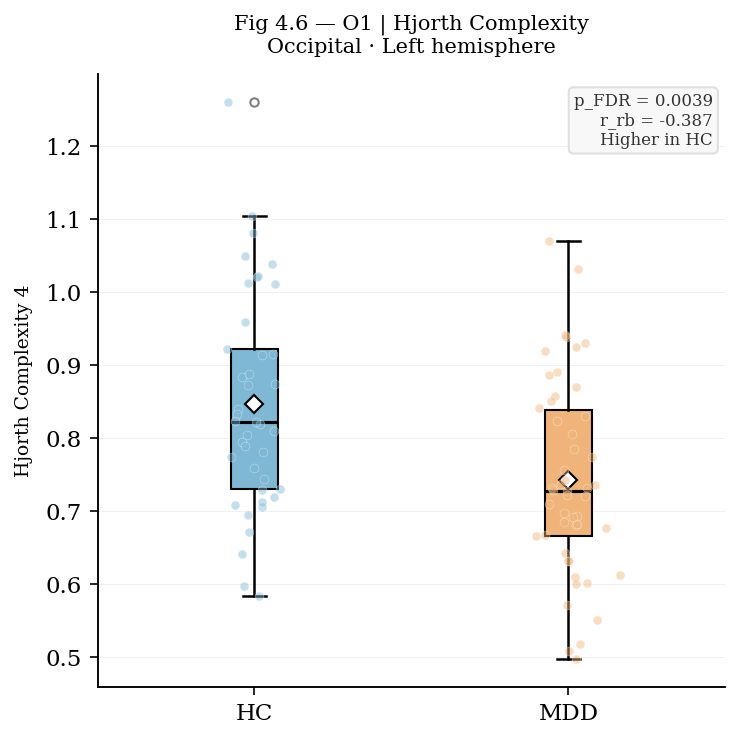


Generating Fig 5 — Spearman correlation heatmap...


KeyboardInterrupt: 

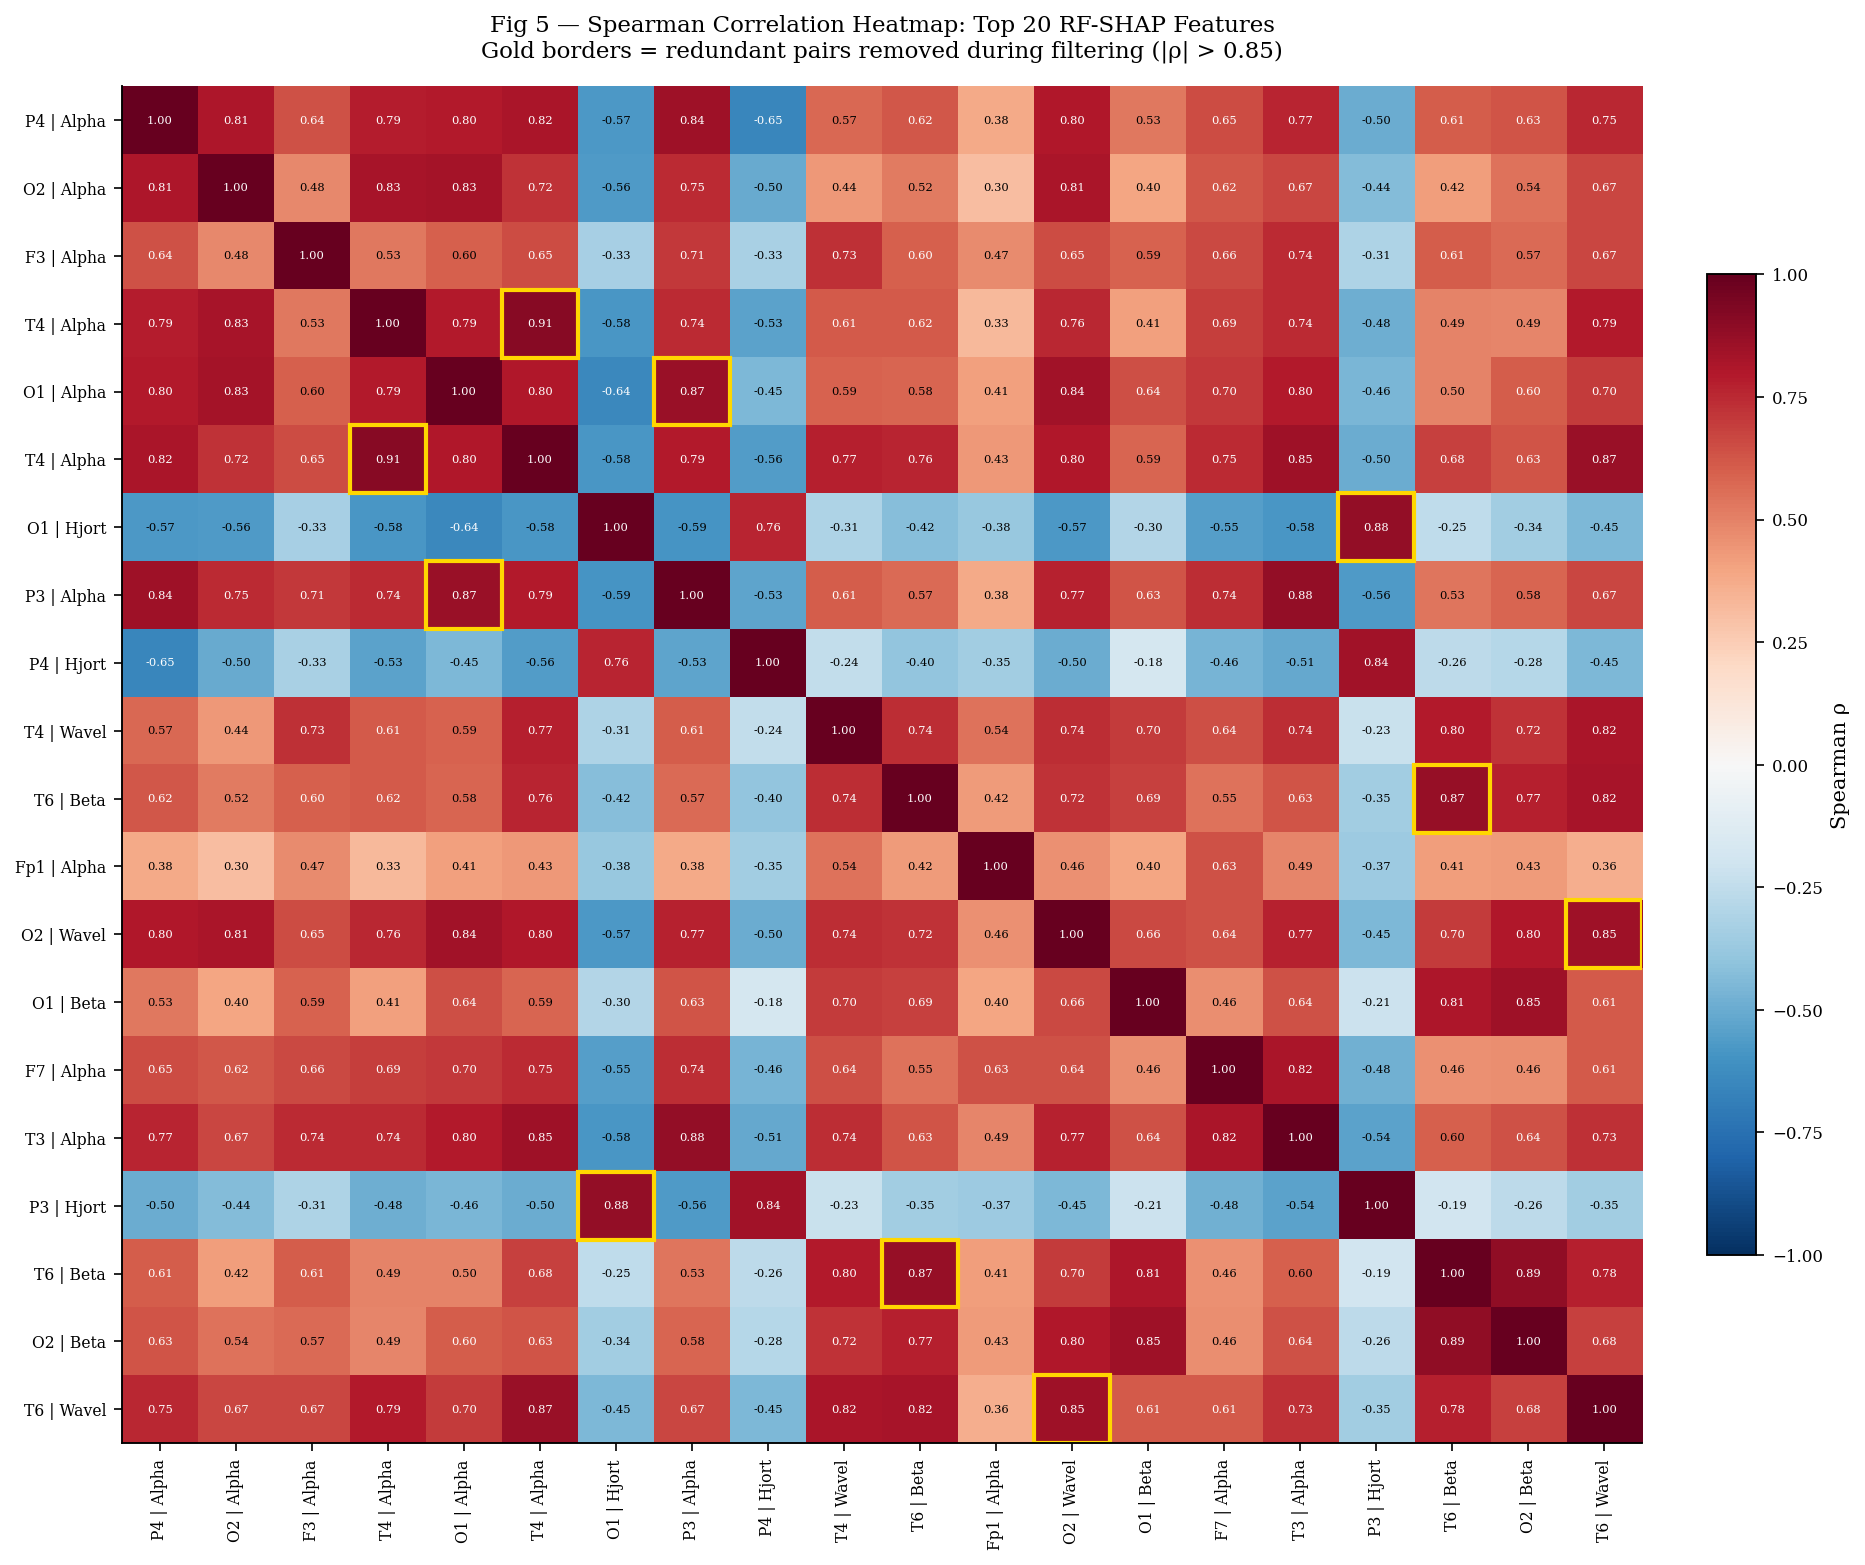

In [13]:
# =============================================================================
# COMPLETE EEG-MDD RF-SHAP BIOMARKER VALIDATION PIPELINE — CLEAN VERSION
# =============================================================================
# All figures saved separately as both PDF and PNG (300 DPI)
# No figure overlaps — proper margins set for each
# Local SHAP panel split into 4 separate figures:
#   Fig 1  — SHAP summary beeswarm plot
#   Fig 2  — SHAP bar plot (top 20)
#   Fig 3  — ROC curves
#   Fig 4  — Boxplots of strongest biomarkers (one per feature, saved separately)
#   Fig 5  — Spearman correlation heatmap
#   Fig 6  — Patient waterfall profiles (3 subplots: correct MDD, correct HC, misclassified)
#   Fig 7  — Patient × Biomarker SHAP heatmap
#   Fig 8  — Global-Local Rank Coherence histogram
#   Fig 9  — Biomarker Local Hit-Rate bar chart
#   Fig 10 — SHAP Sign Consistency in MDD
# Redundant table saves removed — only unique outputs saved
# =============================================================================

# %%
# =============================================================================
# CELL 1 — IMPORTS AND SETTINGS
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc as sklearn_auc
from scipy.stats import shapiro, mannwhitneyu, spearmanr
from statsmodels.stats.multitest import multipletests
import shap

# ── Settings ─────────────────────────────────────────────────────────────────
SEED            = 42
TOP_N           = 20
CORR_THRESHOLD  = 0.85
HC_LABEL        = 0
MDD_LABEL       = 1
MAIN_CLASSIFIERS       = ["RF", "SVM_Lin", "LR", "LDA"]
SUPPLEMENTARY_CLASSIFIERS = ["XGBoost"]

# ── Output folder ─────────────────────────────────────────────────────────────
OUTPUT_DIR = "biomarker_figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Global matplotlib style ───────────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.family':        'serif',
    'font.serif':         ['DejaVu Serif', 'Times New Roman', 'Georgia'],
    'font.size':          11,
    'axes.linewidth':     0.9,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'xtick.major.size':   4,
    'ytick.major.size':   4,
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'figure.constrained_layout.use': False,
})

def save_fig(fig, name):
    """Save figure as both PDF and PNG with consistent naming."""
    pdf_path = os.path.join(OUTPUT_DIR, f"{name}.pdf")
    png_path = os.path.join(OUTPUT_DIR, f"{name}.png")
    fig.savefig(pdf_path, dpi=300, bbox_inches='tight')
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    print(f"  Saved → {pdf_path}")
    print(f"  Saved → {png_path}")
    plt.show()
    plt.close(fig)

print("=" * 100)
print("EEG-MDD RF-SHAP BIOMARKER PIPELINE — CLEAN SEPARATED FIGURES VERSION")
print("=" * 100)
print(f"Output directory : {OUTPUT_DIR}/")
print(f"Top SHAP features: {TOP_N}")
print(f"Corr threshold   : {CORR_THRESHOLD}")
print("=" * 100)


# %%
# =============================================================================
# CELL 2 — DATA CHECK
# =============================================================================
X_raw_df = pd.DataFrame(X, columns=feature_names)

print("DATA CHECK")
print(f"X shape        : {X.shape}")
print(f"Y shape        : {Y.shape}")
print(f"Feature count  : {len(feature_names)}")
print(f"MDD (label=1)  : {np.sum(Y == MDD_LABEL)}")
print(f"HC  (label=0)  : {np.sum(Y == HC_LABEL)}")


# %%
# =============================================================================
# CELL 3 — CONSENSUS k
# =============================================================================
def get_consensus_k(all_results, classifiers_for_k=None):
    if classifiers_for_k is None:
        classifiers_for_k = MAIN_CLASSIFIERS
    all_ks = []
    for res in all_results:
        for clf in classifiers_for_k:
            if "best_k_log" in res and clf in res["best_k_log"]:
                all_ks.extend(res["best_k_log"][clf])
    if not all_ks:
        raise ValueError("No k values found.")
    consensus_k = Counter(all_ks).most_common(1)[0][0]
    return consensus_k, Counter(all_ks)

consensus_k, k_counter = get_consensus_k(all_nested_results, MAIN_CLASSIFIERS)
print(f"\nConsensus k = {consensus_k}")
print("k distribution:")
for k, cnt in sorted(k_counter.items()):
    print(f"  k={k:<3} → {cnt} selections")


# %%
# =============================================================================
# CELL 4 — FEATURE METADATA MAPPING
# =============================================================================
ELECTRODE_ORDER = [
    'Fp1','F3','C3','P3','O1','F7','T3','T5',
    'Fp2','F4','C4','P4','O2','F8','T4','T6',
    'Fz','Cz','Pz'
]

FEATURE_TYPE_LIST = [
    'Alpha_Band_psd_mean','Beta_Band_psd_mean','Gamma_Band_psd_mean',
    'Theta_Band_psd_mean','Delta_Band_psd_mean',
    'Alpha_Band_psd_variance','Beta_Band_psd_variance','Gamma_Band_psd_variance',
    'Theta_Band_psd_variance','Delta_Band_psd_variance',
    'Fractal_Dimension','Wavelet_Energy','Spectral_Entropy',
    'Hjorth_Activity','Hjorth_Mobility','Hjorth_Complexity'
]

ELECTRODE_META = {
    'Fp1':{'Region':'Prefrontal',       'Lobe':'Frontal',   'Hemisphere':'Left',    'Scalp':'Left prefrontal scalp'},
    'Fp2':{'Region':'Prefrontal',       'Lobe':'Frontal',   'Hemisphere':'Right',   'Scalp':'Right prefrontal scalp'},
    'F3': {'Region':'Frontal',          'Lobe':'Frontal',   'Hemisphere':'Left',    'Scalp':'Left frontal scalp'},
    'F4': {'Region':'Frontal',          'Lobe':'Frontal',   'Hemisphere':'Right',   'Scalp':'Right frontal scalp'},
    'F7': {'Region':'Fronto-temporal',  'Lobe':'Frontal',   'Hemisphere':'Left',    'Scalp':'Left fronto-temporal scalp'},
    'F8': {'Region':'Fronto-temporal',  'Lobe':'Frontal',   'Hemisphere':'Right',   'Scalp':'Right fronto-temporal scalp'},
    'Fz': {'Region':'Frontal midline',  'Lobe':'Frontal',   'Hemisphere':'Midline', 'Scalp':'Frontal midline scalp'},
    'C3': {'Region':'Central',          'Lobe':'Parietal',  'Hemisphere':'Left',    'Scalp':'Left central scalp'},
    'C4': {'Region':'Central',          'Lobe':'Parietal',  'Hemisphere':'Right',   'Scalp':'Right central scalp'},
    'Cz': {'Region':'Central midline',  'Lobe':'Parietal',  'Hemisphere':'Midline', 'Scalp':'Central vertex'},
    'P3': {'Region':'Parietal',         'Lobe':'Parietal',  'Hemisphere':'Left',    'Scalp':'Left parietal scalp'},
    'P4': {'Region':'Parietal',         'Lobe':'Parietal',  'Hemisphere':'Right',   'Scalp':'Right parietal scalp'},
    'Pz': {'Region':'Parietal midline', 'Lobe':'Parietal',  'Hemisphere':'Midline', 'Scalp':'Parietal midline scalp'},
    'O1': {'Region':'Occipital',        'Lobe':'Occipital', 'Hemisphere':'Left',    'Scalp':'Left occipital scalp'},
    'O2': {'Region':'Occipital',        'Lobe':'Occipital', 'Hemisphere':'Right',   'Scalp':'Right occipital scalp'},
    'T3': {'Region':'Temporal',         'Lobe':'Temporal',  'Hemisphere':'Left',    'Scalp':'Left mid-temporal scalp'},
    'T4': {'Region':'Temporal',         'Lobe':'Temporal',  'Hemisphere':'Right',   'Scalp':'Right mid-temporal scalp'},
    'T5': {'Region':'Temporo-parietal', 'Lobe':'Temporal',  'Hemisphere':'Left',    'Scalp':'Left posterior temporal scalp'},
    'T6': {'Region':'Temporo-parietal', 'Lobe':'Temporal',  'Hemisphere':'Right',   'Scalp':'Right posterior temporal scalp'},
}

EXTRA_FEATURE_INFO = {
    'Alpha_Asymmetry_Fp2_minus_Fp1':{'Electrode':'Fp2-Fp1','Region':'Prefrontal',     'Lobe':'Frontal','Hemisphere':'Right-Left','Scalp':'Prefrontal asymmetry','Feature_Type':'Alpha_Asymmetry'},
    'Alpha_Asymmetry_F4_minus_F3':  {'Electrode':'F4-F3',  'Region':'Frontal',         'Lobe':'Frontal','Hemisphere':'Right-Left','Scalp':'Frontal asymmetry',    'Feature_Type':'Alpha_Asymmetry'},
    'Alpha_Asymmetry_F8_minus_F7':  {'Electrode':'F8-F7',  'Region':'Fronto-temporal', 'Lobe':'Frontal','Hemisphere':'Right-Left','Scalp':'Fronto-temporal asymmetry','Feature_Type':'Alpha_Asymmetry'},
    'Theta_Alpha_Ratio_Fp1':{'Electrode':'Fp1','Region':'Prefrontal',     'Lobe':'Frontal','Hemisphere':'Left',   'Scalp':'Left prefrontal scalp',    'Feature_Type':'Theta_Alpha_Ratio'},
    'Theta_Alpha_Ratio_F3': {'Electrode':'F3', 'Region':'Frontal',         'Lobe':'Frontal','Hemisphere':'Left',   'Scalp':'Left frontal scalp',       'Feature_Type':'Theta_Alpha_Ratio'},
    'Theta_Alpha_Ratio_F4': {'Electrode':'F4', 'Region':'Frontal',         'Lobe':'Frontal','Hemisphere':'Right',  'Scalp':'Right frontal scalp',      'Feature_Type':'Theta_Alpha_Ratio'},
    'Theta_Alpha_Ratio_Fp2':{'Electrode':'Fp2','Region':'Prefrontal',     'Lobe':'Frontal','Hemisphere':'Right',  'Scalp':'Right prefrontal scalp',   'Feature_Type':'Theta_Alpha_Ratio'},
    'Theta_Alpha_Ratio_F7': {'Electrode':'F7', 'Region':'Fronto-temporal', 'Lobe':'Frontal','Hemisphere':'Left',   'Scalp':'Left fronto-temporal scalp','Feature_Type':'Theta_Alpha_Ratio'},
    'Theta_Alpha_Ratio_F8': {'Electrode':'F8', 'Region':'Fronto-temporal', 'Lobe':'Frontal','Hemisphere':'Right',  'Scalp':'Right fronto-temporal scalp','Feature_Type':'Theta_Alpha_Ratio'},
    'Theta_Alpha_Ratio_Fz': {'Electrode':'Fz', 'Region':'Frontal midline', 'Lobe':'Frontal','Hemisphere':'Midline','Scalp':'Frontal midline scalp',    'Feature_Type':'Theta_Alpha_Ratio'},
}

rows_meta = []
for i, feat in enumerate(feature_names):
    if i < 304:
        elec_idx  = i // 16
        pos_idx   = i % 16
        electrode = ELECTRODE_ORDER[elec_idx]
        ftype     = FEATURE_TYPE_LIST[pos_idx]
        meta      = ELECTRODE_META[electrode]
        rows_meta.append({'Feature':feat,'CSV_Feature_Index':i,'Electrode':electrode,
                          'Region':meta['Region'],'Lobe':meta['Lobe'],
                          'Hemisphere':meta['Hemisphere'],'Scalp':meta['Scalp'],'Feature_Type':ftype})
    else:
        info = EXTRA_FEATURE_INFO.get(feat,{'Electrode':'Unknown','Region':'Unknown',
                                            'Lobe':'Unknown','Hemisphere':'Unknown',
                                            'Scalp':'Unknown','Feature_Type':'Unknown'})
        rows_meta.append({'Feature':feat,'CSV_Feature_Index':i,
                          'Electrode':info['Electrode'],'Region':info['Region'],
                          'Lobe':info['Lobe'],'Hemisphere':info['Hemisphere'],
                          'Scalp':info['Scalp'],'Feature_Type':info['Feature_Type']})

feature_metadata_df = pd.DataFrame(rows_meta)
print(f"\nFeature metadata mapped: {len(feature_metadata_df)} features")


# %%
# =============================================================================
# CELL 5 — FINAL RF MODEL + SHAP
# =============================================================================
final_rf_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("sel",    SelectKBest(score_func=f_classif, k=consensus_k)),
    ("clf",    RandomForestClassifier(
        n_estimators=200, max_depth=5, max_features="sqrt",
        class_weight="balanced", random_state=SEED, n_jobs=-1))
])
final_rf_pipe.fit(X, Y)

selector        = final_rf_pipe.named_steps["sel"]
scaler_step     = final_rf_pipe.named_steps["scaler"]
rf_clf          = final_rf_pipe.named_steps["clf"]
selected_idx    = selector.get_support(indices=True)
selected_features = [feature_names[i] for i in selected_idx]

X_scaled        = scaler_step.transform(X)
X_selected      = selector.transform(X_scaled)
X_selected_df   = pd.DataFrame(X_selected, columns=selected_features)

print(f"\nFinal RF model: k={consensus_k} features selected")

# SHAP values
explainer = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_selected_df)

if isinstance(shap_values, list):
    shap_mdd = shap_values[1]
elif isinstance(shap_values, np.ndarray):
    shap_mdd = shap_values[:,:,1] if shap_values.ndim == 3 else shap_values
else:
    raise ValueError("Unexpected SHAP output format")

mean_abs_shap    = np.ravel(np.abs(shap_mdd).mean(axis=0))
mean_signed_shap = np.ravel(shap_mdd.mean(axis=0))

shap_ranking_df = pd.DataFrame({
    "Feature": selected_features,
    "Mean_abs_SHAP": mean_abs_shap,
    "Mean_signed_SHAP": mean_signed_shap
}).sort_values("Mean_abs_SHAP", ascending=False).reset_index(drop=True)
shap_ranking_df["SHAP_Rank"] = np.arange(1, len(shap_ranking_df)+1)

top_shap_df  = shap_ranking_df.head(TOP_N).copy()
top_features = top_shap_df["Feature"].tolist()

print(f"SHAP computed. Top {TOP_N} features identified.")


# %%
# =============================================================================
# CELL 6 — FIG 1: SHAP BEESWARM SUMMARY PLOT
# =============================================================================
print("\nGenerating Fig 1 — SHAP beeswarm summary plot...")
fig1, ax1 = plt.subplots(figsize=(10, 8))
plt.sca(ax1)
shap.summary_plot(
    shap_mdd,
    X_selected_df,
    max_display=TOP_N,
    plot_type="dot",
    show=False
)
ax1.set_title(
    f"Fig 1 — RF-SHAP Summary Plot (Top {TOP_N} Features)\n"
    "EEG-MDD Classification · Red = pushes toward MDD | Blue = pushes toward HC",
    fontsize=11, pad=14
)
plt.tight_layout(pad=2.5)
save_fig(fig1, "Fig1_SHAP_beeswarm_summary")


# %%
# =============================================================================
# CELL 7 — FIG 2: SHAP BAR PLOT (TOP 20)
# =============================================================================
print("\nGenerating Fig 2 — SHAP bar plot...")

# Colour code bars by feature type
TYPE_COLORS = {
    'Alpha_Band_psd_mean':     '#7EB8D4',
    'Alpha_Band_psd_variance': '#A8D8EA',
    'Beta_Band_psd_mean':      '#85C9A0',
    'Beta_Band_psd_variance':  '#B8E4C9',
    'Hjorth_Complexity':       '#C4A4D4',
    'Wavelet_Energy':          '#F0C080',
}
DEFAULT_COLOR = '#AAAAAA'

meta_lookup = feature_metadata_df.set_index("Feature")

def get_color(feat):
    try:
        ft = meta_lookup.loc[feat, "Feature_Type"]
        return TYPE_COLORS.get(ft, DEFAULT_COLOR)
    except:
        return DEFAULT_COLOR

bar_colors = [get_color(f) for f in top_shap_df["Feature"]]

fig2, ax2 = plt.subplots(figsize=(11, 9))
bars = ax2.barh(
    top_shap_df["Feature"][::-1],
    top_shap_df["Mean_abs_SHAP"][::-1],
    color=bar_colors[::-1],
    edgecolor='white', linewidth=0.5,
    height=0.72
)

# Value labels
for bar, val in zip(bars, top_shap_df["Mean_abs_SHAP"][::-1]):
    ax2.text(
        bar.get_width() + 0.0003, bar.get_y() + bar.get_height()/2,
        f"{val:.4f}", va='center', ha='left', fontsize=12, color='#333'
    )

# Legend
legend_patches = [
    mpatches.Patch(color=c, label=t.replace('_',' '))
    for t, c in TYPE_COLORS.items()
]
ax2.legend(handles=legend_patches, fontsize=11, loc='lower right',
           framealpha=0.9, edgecolor='#ddd', title='Feature Type', title_fontsize=11)

ax2.set_xlabel("Mean |SHAP value| (mean decrease in impurity)", fontsize=12, labelpad=8)
ax2.set_title(
    f"Fig 2 — Top {TOP_N} RF-SHAP Feature Importance\n"
    "EEG-MDD Classification · Colour-coded by feature type",
    fontsize=12, pad=14
)
ax2.grid(axis='x', linewidth=0.4, color='#eeeeee')
fig2.tight_layout(pad=2.5)
save_fig(fig2, "Fig2_SHAP_bar_plot_top20")


# %%
# =============================================================================
# CELL 8 — FIG 3: ROC CURVES
# =============================================================================
print("\nGenerating Fig 3 — ROC curves...")

clf_colors = {
    'RF': '#F0B47A', 'SVM_Lin': '#7EB8D4',
    'LR': '#85C9A0', 'LDA': '#C4A4D4'
}
clf_ls = {'RF': '--', 'SVM_Lin': '-', 'LR': '-.', 'LDA': ':'}

fig3, ax3 = plt.subplots(figsize=(7, 6.5))

for clf_name in MAIN_CLASSIFIERS:
    if clf_name not in all_nested_results[0].get("all_probs", {}):
        print(f"  Skipping {clf_name} — not in all_probs")
        continue

    auc_vals = []
    y_true_0 = all_nested_results[0]["Y"]
    y_prob_0 = all_nested_results[0]["all_probs"][clf_name]
    fpr_0, tpr_0, _ = roc_curve(y_true_0, y_prob_0)

    for res in all_nested_results:
        fp_, tp_, _ = roc_curve(res["Y"], res["all_probs"][clf_name])
        auc_vals.append(sklearn_auc(fp_, tp_))

    mean_auc = np.mean(auc_vals)
    ax3.plot(
        fpr_0, tpr_0,
        linewidth=2.0,
        linestyle=clf_ls.get(clf_name, '-'),
        color=clf_colors.get(clf_name, '#888'),
        label=f"{clf_name}  (AUC = {mean_auc:.3f})"
    )

ax3.plot([0,1],[0,1], linestyle='--', color='#999', linewidth=1.0, label='Chance (AUC = 0.500)')
ax3.fill_between([0,1],[0,1], alpha=0.03, color='grey')

ax3.set_xlabel("False Positive Rate (1 − Specificity)", fontsize=10, labelpad=8)
ax3.set_ylabel("True Positive Rate (Sensitivity)", fontsize=10, labelpad=8)
ax3.set_title(
    "Fig 3 — ROC Curves: Main EEG Classifiers\n"
    "10-fold nested CV · Seed = 0 · n = 91 (50 MDD, 41 HC)",
    fontsize=11, pad=14
)
ax3.legend(fontsize=9, frameon=True, framealpha=0.92,
           edgecolor='#ddd', loc='lower right')
ax3.set_xlim(-0.02, 1.02)
ax3.set_ylim(-0.02, 1.02)
ax3.grid(linewidth=0.4, color='#eeeeee')
fig3.tight_layout(pad=2.5)
save_fig(fig3, "Fig3_ROC_curves_main_classifiers")


# %%
# =============================================================================
# CELL 9 — STATISTICAL PIPELINE (Normality → MW-U → FDR → Effect Size)
# =============================================================================
print("\nRunning statistical validation pipeline...")

# Shapiro-Wilk
normality_rows = []
for feat in top_features:
    mdd_v = X_raw_df.loc[Y==MDD_LABEL, feat].values
    hc_v  = X_raw_df.loc[Y==HC_LABEL,  feat].values
    sw_m, p_m = shapiro(mdd_v)
    sw_h, p_h = shapiro(hc_v)
    normality_rows.append({
        "Feature": feat,
        "MDD_Shapiro_W": sw_m, "MDD_Shapiro_p": p_m, "MDD_Normal": p_m>=0.05,
        "HC_Shapiro_W":  sw_h, "HC_Shapiro_p":  p_h, "HC_Normal":  p_h>=0.05,
        "Any_NonNormal": (p_m<0.05) or (p_h<0.05)
    })
normality_df = pd.DataFrame(normality_rows)

# Mann-Whitney U + effect size
def rank_biserial(u, n1, n2): return (2*u)/(n1*n2) - 1
def es_label(r):
    ar = abs(r)
    if ar < 0.10: return "Negligible"
    if ar < 0.30: return "Small"
    if ar < 0.50: return "Medium"
    return "Large"

stat_rows = []
for feat in top_features:
    mdd_v = X_raw_df.loc[Y==MDD_LABEL, feat].values
    hc_v  = X_raw_df.loc[Y==HC_LABEL,  feat].values
    u, p  = mannwhitneyu(mdd_v, hc_v, alternative="two-sided")
    r     = rank_biserial(u, len(mdd_v), len(hc_v))
    stat_rows.append({
        "Feature": feat,
        "MDD_median": np.median(mdd_v),
        "MDD_IQR":    np.percentile(mdd_v,75)-np.percentile(mdd_v,25),
        "HC_median":  np.median(hc_v),
        "HC_IQR":     np.percentile(hc_v,75)-np.percentile(hc_v,25),
        "U_statistic": u, "p_value": p,
        "r_rb": r, "Effect_size": es_label(r),
        "Direction": "Higher in MDD" if r>0 else "Higher in HC"
    })
stats_df = pd.DataFrame(stat_rows)

# FDR correction
reject, p_fdr, _, _ = multipletests(stats_df["p_value"].values, alpha=0.05, method="fdr_bh")
stats_df["p_FDR"] = p_fdr
stats_df["Significant_FDR_0.05"] = reject

# Merge everything into final biomarker table
final_stats_df = (stats_df
    .merge(shap_ranking_df[["Feature","SHAP_Rank","Mean_abs_SHAP","Mean_signed_SHAP"]], on="Feature", how="left")
    .merge(normality_df[["Feature","MDD_Shapiro_p","HC_Shapiro_p","Any_NonNormal"]], on="Feature", how="left")
    .merge(feature_metadata_df, on="Feature", how="left")
)
final_stats_df["Candidate_Biomarker"] = (
    (final_stats_df["Significant_FDR_0.05"]==True) &
    (final_stats_df["r_rb"].abs()>=0.30)
)

preferred_cols = [
    "SHAP_Rank","Feature","Electrode","Region","Lobe","Hemisphere","Feature_Type",
    "Mean_abs_SHAP","Mean_signed_SHAP","MDD_median","MDD_IQR","HC_median","HC_IQR",
    "U_statistic","p_value","p_FDR","Significant_FDR_0.05","r_rb","Effect_size",
    "Direction","Candidate_Biomarker","MDD_Shapiro_p","HC_Shapiro_p","Any_NonNormal","Scalp"
]
final_stats_df = final_stats_df[[c for c in preferred_cols if c in final_stats_df.columns]]
final_stats_df = final_stats_df.sort_values(
    ["Candidate_Biomarker","p_FDR","Mean_abs_SHAP"],
    ascending=[False,True,False]
).reset_index(drop=True)

n_candidates = final_stats_df["Candidate_Biomarker"].sum()
print(f"Candidate biomarkers: {n_candidates}/{len(final_stats_df)}")
print(f"Non-normal features : {normality_df['Any_NonNormal'].sum()}/{TOP_N}")


# %%
# =============================================================================
# CELL 10 — SPEARMAN REDUNDANCY FILTERING
# =============================================================================
candidate_df = final_stats_df[final_stats_df["Candidate_Biomarker"]].sort_values(
    "Mean_abs_SHAP", ascending=False).reset_index(drop=True)

kept_features   = []
removed_features = []

for feat in candidate_df["Feature"].tolist():
    keep = True
    for kept in kept_features:
        rho, _ = spearmanr(X_raw_df[feat], X_raw_df[kept])
        if abs(rho) > CORR_THRESHOLD:
            keep = False
            removed_features.append({
                "Removed_Feature": feat, "Correlated_With": kept,
                "Spearman_rho": round(rho,4),
                "Reason": f"|rho| > {CORR_THRESHOLD}"
            })
            break
    if keep:
        kept_features.append(feat)

nonredundant_df    = candidate_df[candidate_df["Feature"].isin(kept_features)].reset_index(drop=True)
removed_redundant_df = pd.DataFrame(removed_features)

print(f"\nNon-redundant biomarkers : {len(nonredundant_df)}")
print(f"Removed as redundant     : {len(removed_features)}")


# %%
# =============================================================================
# CELL 11 — FIG 4: BOXPLOTS (one figure per biomarker, saved separately)
# =============================================================================
print("\nGenerating Fig 4 — Boxplots of non-redundant biomarkers...")

plot_features = nonredundant_df["Feature"].head(6).tolist() if not nonredundant_df.empty else top_features[:6]

BOXPLOT_COLORS = {'MDD': '#F0B47A', 'HC': '#7EB8D4'}

for fi, feat in enumerate(plot_features, 1):
    mdd_v = X_raw_df.loc[Y==MDD_LABEL, feat].values
    hc_v  = X_raw_df.loc[Y==HC_LABEL,  feat].values

    meta_row = feature_metadata_df[feature_metadata_df["Feature"]==feat]
    if len(meta_row) > 0:
        mr    = meta_row.iloc[0]
        label = f"{mr['Electrode']} | {mr['Feature_Type'].replace('_',' ')}"
        region = f"{mr['Region']} · {mr['Hemisphere']} hemisphere"
    else:
        label  = feat
        region = ""

    fig_bp, ax_bp = plt.subplots(figsize=(5.5, 5.5))

    bp = ax_bp.boxplot(
        [hc_v, mdd_v],
        labels=["HC", "MDD"],
        patch_artist=True,
        showmeans=True,
        meanprops=dict(marker='D', markerfacecolor='white',
                       markeredgecolor='black', markersize=6),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        medianprops=dict(color='black', linewidth=1.5),
        flierprops=dict(marker='o', markersize=4, alpha=0.5)
    )

    bp['boxes'][0].set_facecolor(BOXPLOT_COLORS['HC'])
    bp['boxes'][1].set_facecolor(BOXPLOT_COLORS['MDD'])

    # Overlay individual data points
    for i, (vals, col) in enumerate([(hc_v, BOXPLOT_COLORS['HC']),
                                      (mdd_v, BOXPLOT_COLORS['MDD'])], 1):
        jitter = np.random.normal(0, 0.05, size=len(vals))
        ax_bp.scatter(
            np.full(len(vals), i) + jitter, vals,
            color=col, alpha=0.45, s=18, zorder=3, edgecolors='white', linewidths=0.3
        )

    ax_bp.set_ylabel(feat.replace('_',' '), fontsize=9, labelpad=6)
    ax_bp.set_title(
        f"Fig 4.{fi} — {label}\n{region}",
        fontsize=10, pad=10
    )
    ax_bp.grid(axis='y', linewidth=0.4, color='#eeeeee')

    # Add p-value annotation
    feat_row = final_stats_df[final_stats_df["Feature"]==feat]
    if len(feat_row) > 0:
        p_fdr_val = feat_row.iloc[0]["p_FDR"]
        r_val     = feat_row.iloc[0]["r_rb"]
        direction = feat_row.iloc[0]["Direction"]
        ax_bp.text(
            0.98, 0.97,
            f"p_FDR = {p_fdr_val:.4f}\nr_rb = {r_val:.3f}\n{direction}",
            transform=ax_bp.transAxes, fontsize=8,
            va='top', ha='right', color='#333',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#f8f8f8',
                      edgecolor='#ddd', alpha=0.9)
        )

    fig_bp.tight_layout(pad=2.5)
    safe_name = feat.replace("/","_").replace(" ","_")
    save_fig(fig_bp, f"Fig4_{fi}_boxplot_{safe_name}")


# %%
# =============================================================================
# CELL 12 — FIG 5: SPEARMAN CORRELATION HEATMAP
# =============================================================================
print("\nGenerating Fig 5 — Spearman correlation heatmap...")

corr_matrix = X_raw_df[top_features].corr(method="spearman")

fig5, ax5 = plt.subplots(figsize=(13, 11))
im = ax5.imshow(corr_matrix.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
cbar = plt.colorbar(im, ax=ax5, fraction=0.03, pad=0.04)
cbar.set_label("Spearman ρ", fontsize=10)
cbar.ax.tick_params(labelsize=8)

short_labels = []
for f in top_features:
    try:
        mr = feature_metadata_df[feature_metadata_df["Feature"]==f].iloc[0]
        short_labels.append(f"{mr['Electrode']} | {mr['Feature_Type'].split('_')[0][:5]}")
    except:
        short_labels.append(f[:20])

ax5.set_xticks(range(len(top_features)))
ax5.set_yticks(range(len(top_features)))
ax5.set_xticklabels(short_labels, rotation=90, fontsize=7.5)
ax5.set_yticklabels(short_labels, fontsize=7.5)

# Annotate cells
for i in range(len(top_features)):
    for j in range(len(top_features)):
        val = corr_matrix.values[i,j]
        txt_col = 'white' if abs(val) > 0.6 else 'black'
        ax5.text(j, i, f"{val:.2f}", ha='center', va='center',
                 fontsize=5.5, color=txt_col)

# Mark redundant pairs
if not removed_redundant_df.empty:
    for _, row_r in removed_redundant_df.iterrows():
        if row_r["Removed_Feature"] in top_features and row_r["Correlated_With"] in top_features:
            ri = top_features.index(row_r["Removed_Feature"])
            ci = top_features.index(row_r["Correlated_With"])
            for (r_,c_) in [(ri,ci),(ci,ri)]:
                ax5.add_patch(plt.Rectangle(
                    (c_-0.5, r_-0.5), 1, 1,
                    fill=False, edgecolor='gold', linewidth=2.0
                ))

ax5.set_title(
    f"Fig 5 — Spearman Correlation Heatmap: Top {TOP_N} RF-SHAP Features\n"
    "Gold borders = redundant pairs removed during filtering (|ρ| > 0.85)",
    fontsize=11, pad=14
)
fig5.tight_layout(pad=2.5)
save_fig(fig5, "Fig5_spearman_correlation_heatmap")


# %%
# =============================================================================
# CELL 13 — LOCAL SHAP SETUP
# =============================================================================
print("\nSetting up local SHAP analysis...")

final_biomarkers = final_stats_df["Feature"].head(10).tolist()
final_biomarkers = [f for f in final_biomarkers if f in list(X_selected_df.columns)]

def local_label(feature):
    row = feature_metadata_df[feature_metadata_df["Feature"]==feature]
    if len(row)==0: return feature
    r = row.iloc[0]
    return f"{r['Electrode']} | {r['Feature_Type'].replace('_Band_psd_','_').replace('_',' ')[:22]}"

bio_labels  = [local_label(f) for f in final_biomarkers]
bio_indices = [list(X_selected_df.columns).index(f) for f in final_biomarkers]
shap_bio    = shap_mdd[:, bio_indices]
abs_bio     = np.abs(shap_bio)

preds_proba = final_rf_pipe.predict_proba(X)
preds       = np.argmax(preds_proba, axis=1)

global_bio_importance = (
    shap_ranking_df[shap_ranking_df["Feature"].isin(final_biomarkers)]
    .set_index("Feature")["Mean_abs_SHAP"]
    .reindex(final_biomarkers).fillna(0).values
)
global_rank = np.argsort(-global_bio_importance)

coherence_scores = []
for i in range(X_selected_df.shape[0]):
    local_rank = np.argsort(-abs_bio[i])
    rho, _ = spearmanr(global_rank, local_rank)
    coherence_scores.append(rho)
coherence_scores = np.array(coherence_scores)
mean_coherence   = np.nanmean(coherence_scores)

strong_all = (coherence_scores >= 0.5).sum()
mdd_coherence = coherence_scores[Y==MDD_LABEL]
strong_mdd    = (mdd_coherence >= 0.5).sum()

print(f"Mean global-local rank coherence : {mean_coherence:.3f}")
print(f"Subjects with rho >= 0.5         : {strong_all}/{len(Y)}")
print(f"MDD patients with rho >= 0.5     : {strong_mdd}/{len(mdd_coherence)}")

mdd_correct = np.where((Y==MDD_LABEL) & (preds==MDD_LABEL))[0]
hc_correct  = np.where((Y==HC_LABEL)  & (preds==HC_LABEL))[0]
wrong       = np.where(preds!=Y)[0]

patient_mdd   = mdd_correct[0] if len(mdd_correct)>0 else np.where(Y==MDD_LABEL)[0][0]
patient_hc    = hc_correct[0]  if len(hc_correct)>0  else np.where(Y==HC_LABEL)[0][0]
patient_wrong = wrong[0]       if len(wrong)>0        else None


# %%
# =============================================================================
# CELL 14 — FIG 6: PATIENT WATERFALL PROFILES (3 subplots side by side)
# =============================================================================
print("\nGenerating Fig 6 — Patient waterfall profiles...")

def plot_waterfall(ax, patient_idx, title, title_color='black'):
    vals      = shap_mdd[patient_idx]
    top_k     = min(10, len(vals))
    top_idx   = np.argsort(np.abs(vals))[-top_k:][::-1]
    top_vals  = vals[top_idx]
    top_feats = X_selected_df.columns[top_idx]
    top_labs  = [local_label(f) for f in top_feats]
    colors    = ['#C44E52' if v>0 else '#4C72B0' for v in top_vals]

    ax.barh(range(top_k), top_vals[::-1],
            color=colors[::-1], alpha=0.85,
            edgecolor='white', linewidth=0.4, height=0.7)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(top_labs[::-1], fontsize=8)
    ax.axvline(0, color='black', linewidth=0.9)
    ax.set_title(title, fontsize=9.5, fontweight='bold', color=title_color, pad=8)
    ax.set_xlabel("SHAP value\n→ MDD  |  ← HC", fontsize=8, labelpad=5)
    ax.grid(axis='x', linewidth=0.4, color='#eeeeee')
    prob = preds_proba[patient_idx][MDD_LABEL]
    true_lbl = "MDD" if Y[patient_idx]==MDD_LABEL else "HC"
    pred_lbl = "MDD" if preds[patient_idx]==MDD_LABEL else "HC"
    ax.text(0.98, 0.02,
            f"True: {true_lbl}\nPred: {pred_lbl}\nP(MDD): {prob:.2f}",
            transform=ax.transAxes, fontsize=7.5, va='bottom', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#f8f8f8',
                      edgecolor='#ddd', alpha=0.9))

fig6, axes6 = plt.subplots(1, 3, figsize=(18, 7))
fig6.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.12, wspace=0.45)

plot_waterfall(axes6[0], patient_mdd,
               f"Correct MDD — Subject #{patient_mdd}", title_color='#C44E52')
plot_waterfall(axes6[1], patient_hc,
               f"Correct HC — Subject #{patient_hc}", title_color='#4C72B0')

if patient_wrong is not None:
    tl = "MDD" if Y[patient_wrong]==MDD_LABEL else "HC"
    pl = "MDD" if preds[patient_wrong]==MDD_LABEL else "HC"
    plot_waterfall(axes6[2], patient_wrong,
                   f"Misclassified — Subject #{patient_wrong}\nTrue={tl}, Pred={pl}",
                   title_color='#856404')
else:
    axes6[2].text(0.5, 0.5, "No misclassified\nsubjects found",
                  ha='center', va='center', fontsize=11, color='#888')
    axes6[2].set_title("Misclassified Subject", fontsize=9.5, fontweight='bold', pad=8)
    axes6[2].axis('off')

fig6.suptitle(
    "Fig 6 — Local RF-SHAP Patient-Level Biomarker Profiles\n"
    "Red bars = features pushing toward MDD · Blue bars = features pushing toward HC",
    fontsize=11, y=0.98
)
save_fig(fig6, "Fig6_patient_waterfall_profiles")


# %%
# =============================================================================
# CELL 15 — FIG 7: PATIENT × BIOMARKER SHAP HEATMAP
# =============================================================================
print("\nGenerating Fig 7 — Patient × Biomarker SHAP heatmap...")

mdd_idx = np.where(Y == MDD_LABEL)[0]
hc_idx  = np.where(Y == HC_LABEL)[0]

patient_order = np.concatenate([
    mdd_idx[np.argsort(-coherence_scores[mdd_idx])],
    hc_idx[np.argsort(-coherence_scores[hc_idx])]
])

heatmap_data = shap_bio[patient_order]
vlim = np.percentile(np.abs(shap_bio), 95)

fig7, ax7 = plt.subplots(figsize=(12, 7.5), dpi=300)
fig7.subplots_adjust(left=0.28, right=0.90, top=0.82, bottom=0.15)

im7 = ax7.imshow(
    heatmap_data.T,
    aspect='auto',
    cmap='RdBu_r',
    vmin=-vlim,
    vmax=vlim,
    interpolation='nearest'
)

# Colorbar
cbar7 = fig7.colorbar(im7, ax=ax7, fraction=0.035, pad=0.025)
cbar7.set_label("SHAP value", fontsize=14, fontweight='bold')
cbar7.ax.tick_params(labelsize=12)

# Axis labels
ax7.set_yticks(range(len(bio_labels)))
ax7.set_yticklabels(bio_labels, fontsize=13)

ax7.set_xlabel(
    "Subjects sorted by diagnostic group and local coherence",
    fontsize=14,
    fontweight='bold',
    labelpad=10
)

ax7.set_ylabel(
    "EEG Biomarkers",
    fontsize=14,
    fontweight='bold',
    labelpad=10
)

ax7.tick_params(axis='x', labelsize=11)
ax7.tick_params(axis='y', labelsize=12)

# Remove x tick labels if too crowded
ax7.set_xticks([])

# Group divider
divider_x = len(mdd_idx) - 0.5
ax7.axvline(divider_x, color='black', linestyle='--', linewidth=1.8)

# Group labels ABOVE heatmap
ax7.text(
    len(mdd_idx) / 2,
    1.03,
    "MDD",
    ha='center',
    va='bottom',
    fontsize=15,
    fontweight='bold',
    color='#C44E52',
    transform=ax7.get_xaxis_transform()
)

ax7.text(
    len(mdd_idx) + len(hc_idx) / 2,
    1.03,
    "HC",
    ha='center',
    va='bottom',
    fontsize=15,
    fontweight='bold',
    color='#4C72B0',
    transform=ax7.get_xaxis_transform()
)

# Title
ax7.set_title(
    "Patient × Biomarker SHAP Heatmap",
    fontsize=16,
    fontweight='bold',
    pad=34
)

# Small subtitle
fig7.text(
    0.5, 0.91,
    "Red indicates contribution toward MDD; blue indicates contribution toward HC",
    ha='center',
    fontsize=13
)

save_fig(fig7, "Fig7_patient_biomarker_SHAP_heatmap")

# %%
# =============================================================================
# CELL 16 — FIG 8: GLOBAL-LOCAL RANK COHERENCE HISTOGRAM
# =============================================================================
print("\nGenerating Fig 8 — Global-local rank coherence histogram...")

fig8, ax8 = plt.subplots(figsize=(7, 5.5))
fig8.subplots_adjust(left=0.12, right=0.95, top=0.88, bottom=0.14)

bins = np.linspace(-1, 1, 22)
ax8.hist(coherence_scores[Y==MDD_LABEL], bins=bins, alpha=0.70,
         color='#F0B47A', edgecolor='white', linewidth=0.4, label='MDD')
ax8.hist(coherence_scores[Y==HC_LABEL],  bins=bins, alpha=0.70,
         color='#7EB8D4', edgecolor='white', linewidth=0.4, label='HC')

ax8.axvline(mean_coherence, color='black', linestyle='--', linewidth=1.5,
            label=f'Mean ρ = {mean_coherence:.3f}')
ax8.axvline(0.5, color='#2E7D5E', linestyle=':', linewidth=1.5,
            label='Threshold ρ = 0.50')

ax8.set_xlabel("Spearman ρ (global-local rank coherence)", fontsize=10, labelpad=7)
ax8.set_ylabel("Number of subjects", fontsize=10, labelpad=7)
ax8.set_title(
    "Fig 8 — Global-Local SHAP Rank Coherence Distribution\n"
    f"n={len(Y)} · Strong coherence (ρ ≥ 0.5): {strong_all}/{len(Y)} subjects · "
    f"MDD: {strong_mdd}/{len(mdd_coherence)}",
    fontsize=10, pad=12
)
ax8.legend(fontsize=9, frameon=True, framealpha=0.9, edgecolor='#ddd')
ax8.grid(axis='y', linewidth=0.4, color='#eeeeee')
save_fig(fig8, "Fig8_global_local_rank_coherence")


# %%
# =============================================================================
# CELL 17 — FIG 9: BIOMARKER LOCAL HIT-RATE
# =============================================================================
print("\nGenerating Fig 9 — Biomarker local hit-rate...")

hit_rate_mdd = []
hit_rate_hc  = []
local_ranks_mdd = np.argsort(-abs_bio[Y==MDD_LABEL], axis=1)
local_ranks_hc  = np.argsort(-abs_bio[Y==HC_LABEL],  axis=1)

for bi in range(len(final_biomarkers)):
    pos_mdd = np.where(local_ranks_mdd==bi)[1]
    pos_hc  = np.where(local_ranks_hc==bi)[1]
    hit_rate_mdd.append((pos_mdd<5).mean())
    hit_rate_hc.append((pos_hc<5).mean())

x9    = np.arange(len(bio_labels))
width = 0.38

fig9, ax9 = plt.subplots(figsize=(12, 6))
fig9.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.28)

bars_mdd = ax9.bar(x9 - width/2, hit_rate_mdd, width,
                   label='MDD', color='#F0B47A',
                   edgecolor='white', linewidth=0.5, alpha=0.9)
bars_hc  = ax9.bar(x9 + width/2, hit_rate_hc,  width,
                   label='HC',  color='#7EB8D4',
                   edgecolor='white', linewidth=0.5, alpha=0.9)

# Value labels on bars
for bar in bars_mdd:
    h = bar.get_height()
    if h > 0.02:
        ax9.text(bar.get_x()+bar.get_width()/2, h+0.01,
                 f"{h:.2f}", ha='center', va='bottom', fontsize=7)
for bar in bars_hc:
    h = bar.get_height()
    if h > 0.02:
        ax9.text(bar.get_x()+bar.get_width()/2, h+0.01,
                 f"{h:.2f}", ha='center', va='bottom', fontsize=7)

ax9.axhline(0.40, color='black', linestyle='--', linewidth=1.0,
            label='Hit-rate threshold (0.40)')
ax9.set_xticks(x9)
ax9.set_xticklabels(bio_labels, rotation=55, ha='right', fontsize=8)
ax9.set_ylabel("Hit-rate (top-5 local driver frequency)", fontsize=10, labelpad=7)
ax9.set_ylim(0, 1.05)
ax9.set_title(
    "Fig 9 — Biomarker Local Hit-Rate: MDD vs HC\n"
    "Proportion of subjects where each biomarker ranks in top-5 local SHAP drivers",
    fontsize=10, pad=12
)
ax9.legend(fontsize=9, frameon=True, framealpha=0.9, edgecolor='#ddd')
ax9.grid(axis='y', linewidth=0.4, color='#eeeeee')
save_fig(fig9, "Fig9_biomarker_local_hitrate")


# %%
# =============================================================================
# CELL 18 — FIG 10: SHAP SIGN CONSISTENCY
# =============================================================================
print("\nGenerating Fig 10 — SHAP sign consistency...")

sign_consistency = []
verdict_rows     = []
for bi, bio in enumerate(final_biomarkers):
    signs = np.sign(shap_bio[Y==MDD_LABEL, bi])
    maj   = np.sign(signs.sum())
    cons  = 0.5 if maj==0 else (signs==maj).mean()
    sign_consistency.append(cons)
    hr = hit_rate_mdd[bi]
    if hr>=0.40 and cons>=0.70:   verdict = "Strong VALID"
    elif hr>=0.25 and cons>=0.70: verdict = "Moderate VALID"
    elif hr>=0.40 and cons>=0.50: verdict = "Moderate"
    else:                          verdict = "Weak"
    verdict_rows.append({
        "Biomarker": bio, "Label": bio_labels[bi],
        "HitRate_MDD": round(hr,3), "SignConsistency_MDD": round(cons,3),
        "Verdict": verdict
    })

local_validity_df = pd.DataFrame(verdict_rows)

verdict_colors = {
    "Strong VALID":   '#85C9A0',
    "Moderate VALID": '#7EB8D4',
    "Moderate":       '#F0C080',
    "Weak":           '#F0B47A',
}
bar_colors_sc = [verdict_colors.get(v, '#aaa') for v in local_validity_df["Verdict"][::-1]]

fig10, ax10 = plt.subplots(figsize=(9, 7))
fig10.subplots_adjust(left=0.32, right=0.92, top=0.88, bottom=0.10)

bars_sc = ax10.barh(bio_labels[::-1], sign_consistency[::-1],
                    color=bar_colors_sc, edgecolor='white',
                    linewidth=0.5, alpha=0.9, height=0.72)

# Value labels
for bar, val in zip(bars_sc, sign_consistency[::-1]):
    ax10.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
              f"{val:.2f}", va='center', ha='left', fontsize=8)

ax10.axvline(0.70, color='black', linestyle='--', linewidth=1.2,
             label='Threshold = 0.70')
ax10.set_xlabel("Fraction of MDD subjects agreeing with majority SHAP direction",
                fontsize=9, labelpad=7)
ax10.set_title(
    "Fig 10 — SHAP Sign Consistency in MDD Group\n"
    "Colour indicates local validity verdict",
    fontsize=10, pad=12
)
ax10.set_xlim(0, 1.12)
ax10.grid(axis='x', linewidth=0.4, color='#eeeeee')

legend_patches = [
    mpatches.Patch(color=c, label=v)
    for v, c in verdict_colors.items()
]
ax10.legend(handles=legend_patches, fontsize=8.5, loc='lower right',
            framealpha=0.9, edgecolor='#ddd', title='Verdict', title_fontsize=8)
save_fig(fig10, "Fig10_SHAP_sign_consistency")


# %%
# =============================================================================
# CELL 19 — SAVE ALL TABLES (non-redundant, unique outputs only)
# =============================================================================
print("\nSaving tables...")

# 1. Feature metadata — full mapping (unique)
feature_metadata_df.to_csv(
    os.path.join(OUTPUT_DIR, "Table_S1_feature_metadata_314.csv"), index=False)

# 2. SHAP ranking — all 30 selected features
shap_ranking_df.to_csv(
    os.path.join(OUTPUT_DIR, "Table_S2_SHAP_ranking_all_selected.csv"), index=False)

# 3. Final biomarker table — complete statistical output (replaces multiple redundant saves)
final_stats_df.to_csv(
    os.path.join(OUTPUT_DIR, "Table_S3_final_biomarker_stats_complete.csv"), index=False)

# 4. Non-redundant biomarkers — paper-ready
nonredundant_df.to_csv(
    os.path.join(OUTPUT_DIR, "Table_Main_nonredundant_biomarkers.csv"), index=False)

# 5. Removed redundant features — supplementary
if not removed_redundant_df.empty:
    removed_redundant_df.to_csv(
        os.path.join(OUTPUT_DIR, "Table_S4_removed_redundant_features.csv"), index=False)

# 6. Local validity verdicts
local_validity_df.to_csv(
    os.path.join(OUTPUT_DIR, "Table_S5_local_SHAP_validity_verdicts.csv"), index=False)

# 7. Region/electrode/hemisphere prominence
for name, df_ in [
    ("region",     final_stats_df["Region"].value_counts().reset_index()),
    ("lobe",       final_stats_df["Lobe"].value_counts().reset_index()),
    ("electrode",  final_stats_df["Electrode"].value_counts().reset_index()),
    ("hemisphere", final_stats_df["Hemisphere"].value_counts().reset_index()),
]:
    df_.columns = [name.capitalize(), "Count"]
    df_.to_csv(os.path.join(OUTPUT_DIR, f"Table_S6_{name}_prominence.csv"), index=False)

print("\n" + "="*70)
print("ALL OUTPUTS SAVED")
print("="*70)
print(f"\nFigures directory : {OUTPUT_DIR}/")
print("\nFigures saved (PDF + PNG each):")
for i, name in enumerate([
    "Fig1_SHAP_beeswarm_summary",
    "Fig2_SHAP_bar_plot_top20",
    "Fig3_ROC_curves_main_classifiers",
    "Fig4_1-6_boxplots_per_biomarker",
    "Fig5_spearman_correlation_heatmap",
    "Fig6_patient_waterfall_profiles",
    "Fig7_patient_biomarker_SHAP_heatmap",
    "Fig8_global_local_rank_coherence",
    "Fig9_biomarker_local_hitrate",
    "Fig10_SHAP_sign_consistency",
], 1):
    print(f"  {name}")

print("\nTables saved (CSV):")
for t in [
    "Table_S1_feature_metadata_314.csv",
    "Table_S2_SHAP_ranking_all_selected.csv",
    "Table_S3_final_biomarker_stats_complete.csv",
    "Table_Main_nonredundant_biomarkers.csv",
    "Table_S4_removed_redundant_features.csv",
    "Table_S5_local_SHAP_validity_verdicts.csv",
    "Table_S6_region/lobe/electrode/hemisphere_prominence.csv",
]:
    print(f"  {t}")
print("="*70)


# %%
# =============================================================================
# CELL 20 — PRINT FINAL SUMMARY
# =============================================================================
print("\n" + "="*70)
print("ANALYSIS SUMMARY")
print("="*70)
print(f"Dataset              : n={len(Y)} (MDD={np.sum(Y==1)}, HC={np.sum(Y==0)})")
print(f"Consensus k          : {consensus_k}")
print(f"Top SHAP features    : {TOP_N}")
print(f"Non-normal features  : {normality_df['Any_NonNormal'].sum()}/{TOP_N}")
print(f"Candidate biomarkers : {n_candidates}/{TOP_N} (FDR q<0.05, |r|≥0.30)")
print(f"Non-redundant        : {len(nonredundant_df)} (after Spearman |ρ|>{CORR_THRESHOLD} filtering)")
print(f"Mean coherence (ρ)   : {mean_coherence:.3f}")
print(f"Strong coherence     : {strong_mdd}/{len(mdd_coherence)} MDD patients (rho≥0.5)")
print("\nLocal Validity Verdicts:")
for _, row_v in local_validity_df.iterrows():
    print(f"  {row_v['Label']:<35} HR={row_v['HitRate_MDD']:.3f}  SC={row_v['SignConsistency_MDD']:.3f}  → {row_v['Verdict']}")
print("="*70)

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import mne

# ── Electrode names ───────────────────────────────────────────
electrode_names = [
    'Fp1','F3','C3','P3','O1','F7','T3','T5',
    'Fp2','F4','C4','P4','O2','F8','T4','T6',
    'Fz','Cz','Pz'
]

# ── Build per-electrode SHAP values ──────────────────────────
def get_electrode_shap(feature_type_keyword):
    shap_map = {elec: 0.0 for elec in electrode_names}
    subset = final_stats_df[
        final_stats_df['Feature_Type'].str.contains(
            feature_type_keyword, case=False, na=False
        )
    ]
    for _, row in subset.iterrows():
        elec = row['Electrode']
        shap_val = row['Mean_abs_SHAP']
        if elec in shap_map:
            shap_map[elec] = max(shap_map[elec], shap_val)
    return np.array([shap_map[e] for e in electrode_names])

alpha_array   = get_electrode_shap('Alpha_Band_psd_mean')
beta_array    = get_electrode_shap('Beta_Band_psd')
hjorth_array  = get_electrode_shap('Hjorth_Complexity')
wavelet_array = get_electrode_shap('Wavelet_Energy')

# ── MNE info and montage ──────────────────────────────────────
info = mne.create_info(
    ch_names=electrode_names,
    sfreq=256,
    ch_types='eeg'
)
info.set_montage('standard_1020')

montage  = mne.channels.make_standard_montage('standard_1020')
pos_dict = {
    ch: montage.get_positions()['ch_pos'][ch][:2]
    for ch in electrode_names
    if ch in montage.get_positions()['ch_pos']
}

# ── Light pastel colormap ─────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap

colors_light = [
    '#4575b4',  # deep blue  — zero/low
    '#91bfdb',  # light blue
    '#e0f3f8',  # very pale blue
    '#ffffbf',  # pale yellow — mid
    '#fee090',  # light orange
    '#fc8d59',  # orange
    '#d73027',  # red        — high
]
CMAP = LinearSegmentedColormap.from_list(
    'shap_light', colors_light, N=256
)

# ── Helper function to plot one topomap ───────────────────────
def plot_one_topo(ax, data, title, show_cbar=False):
    vmax = float(data.max()) if data.max() > 0 else 0.01
    vmin = 0.0

    try:
        im, _ = mne.viz.plot_topomap(
            data, info, axes=ax, show=False,
            cmap=CMAP, vmin=vmin, vmax=vmax,
            contours=5, sphere=0.095,
            sensors=False,
            names=electrode_names
        )
    except TypeError:
        im, _ = mne.viz.plot_topomap(
            data, info, axes=ax, show=False,
            cmap=CMAP, vlim=(vmin, vmax),
            contours=5, sphere=0.095,
            sensors=False,
            names=electrode_names
        )

    # Electrode labels
    for ch_name in electrode_names:
        if ch_name in pos_dict:
            x, y = pos_dict[ch_name]
            ax.text(
                x, y, ch_name,
                fontsize=13,
                fontweight='bold',
                ha='center', va='center',
                color='#111111',
                bbox=dict(
                    boxstyle='round,pad=0.15',
                    facecolor='white',
                    edgecolor='none',
                    alpha=0.65
                )
            )

    ax.set_title(
        title,
        fontsize=16,
        fontweight='bold',
        pad=20,
        color='#111111'
    )

    if show_cbar:
        cbar = plt.colorbar(
            im, ax=ax,
            orientation='vertical',
            fraction=0.046,
            pad=0.06,
            shrink=0.85
        )
        cbar.set_label('Mean |SHAP|', fontsize=12, labelpad=10)
        cbar.ax.tick_params(labelsize=13)

    return im

# ── ROW 1: Alpha Power + Beta Power ──────────────────────────
fig1, axes1 = plt.subplots(
    1, 2,
    figsize=(16, 8),
    gridspec_kw={'wspace': 0.20}
)

plot_one_topo(axes1[0], alpha_array,  'Alpha Power',  show_cbar=True)
plot_one_topo(axes1[1], beta_array,   'Beta Power',   show_cbar=True)

fig1.suptitle(
    'SHAP Importance Topographic Maps (1/2)\n'
    'EEG-MDD Classification — Spectral Power Features',
    fontsize=17, fontweight='bold', y=1.02
)

plt.savefig('shap_topomap_row1.pdf', dpi=300, bbox_inches='tight')
plt.savefig('shap_topomap_row1.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved → shap_topomap_row1")

# ── ROW 2: Hjorth Complexity + Wavelet Energy ─────────────────
fig2, axes2 = plt.subplots(
    1, 2,
    figsize=(16, 8),
    gridspec_kw={'wspace': 0.20}
)

plot_one_topo(axes2[0], hjorth_array,  'Hjorth Complexity', show_cbar=True)
plot_one_topo(axes2[1], wavelet_array, 'Wavelet Energy',    show_cbar=True)

fig2.suptitle(
    'SHAP Importance Topographic Maps (2/2)\n'
    'EEG-MDD Classification — Complexity and Time-Frequency Features',
    fontsize=17, fontweight='bold', y=1.02
)

plt.savefig('shap_topomap_row2.pdf', dpi=300, bbox_inches='tight')
plt.savefig('shap_topomap_row2.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved → shap_topomap_row2")

C:\Users\welcome\anaconda3\lib\site-packages\mne\io\open.py:160: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dirpos = int(tag.data)
C:\Users\welcome\anaconda3\lib\site-packages\mne\io\tag.py:299: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  version=int(np.frombuffer(fid.read(4), dtype=">i4")),
C:\Users\welcome\anaconda3\lib\site-packages\mne\io\tag.py:301: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  secs=int(np.frombuffer(fid.read(4), dtype=">i4")),
C:\Users\w

Saved → shap_topomap_row1


C:\Users\welcome\anaconda3\lib\site-packages\mne\viz\topomap.py:976: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for col in cont.collections:
C:\Users\welcome\anaconda3\lib\site-packages\mne\viz\topomap.py:976: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for col in cont.collections:


Saved → shap_topomap_row2
